### ROUGH DRAFT NOTEBOOK FOR FORECASTING MODEL

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


In [2]:
path = Path('projections')
projects = {}

for file in sorted(path.glob('*.csv'), key=lambda p: p.name):
    current_df = pd.read_csv(file)
    file_name = file.stem
    projects[file_name] = current_df

In [3]:
# Some formatting/ cleaning up stuff
for name, df in projects.items():
    df_cleaned = df.iloc[:, 1:].copy()

    if len(df_cleaned) > 0:
        df_cleaned.iat[-1, 0] = "Total"

        start_col_idx = 6
        if df_cleaned.shape[1] > start_col_idx:
            last_row = df_cleaned.iloc[[-1], start_col_idx:]
            cleaned_last_row = (
                last_row.astype("string")
                .apply(lambda s: s.str.split(r"\r\n|\n|\r", regex=True).str[0])
            )
            df_cleaned.iloc[-1, start_col_idx:] = cleaned_last_row.iloc[0].to_numpy()

    df_cleaned = df_cleaned.reset_index(drop=True)
    projects[name] = df_cleaned

In [4]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
master_timeline = timeline_dates.strftime('%b %Y').tolist()

for name, df in projects.items():
    static_columns = list(df.columns[:7])
    all_desired_columns = static_columns + master_timeline
    df_unified = df.reindex(columns=all_desired_columns, fill_value=0)
    projects[name] = df_unified

In [5]:
# Drop all categories and leave only totals
for name, df in projects.items():
    # --- START OF TRY-EXCEPT BLOCK ---
    try:
        # Find the row where the first column equals "Total"
        total_only = df[df.iloc[:, 0].astype(str).eq("Total")].copy()
        
        # Attempt to drop the specific text columns
        total_only = total_only.drop(columns=["Line Item", "Description"])
        
        # Save it back to the dictionary
        projects[name] = total_only.reset_index(drop=True)
        
    except Exception as e:
        print(f"⚠️ Failed to process totals for project: {name}")
        print(f"   Reason: {e}\n")
    # --- END OF TRY-EXCEPT BLOCK ---

In [6]:
# Add project code as first column
for name, df in projects.items():
    if df.empty:
        continue

    if "Project Code" in df.columns:
        df = df.drop(columns=["Project Code"])
    df.insert(0, "Project Code", name)

    projects[name] = df

In [7]:
# Squish all projects into a single dataframe
non_empty_projects = [df for df in projects.values() if not df.empty]
all_projects_df = pd.concat(non_empty_projects, ignore_index=True)

In [8]:
import os

# Remove "Actuals" columns (I don't think we need these?)
cols_to_drop = ["Actuals To Date", "Actuals + Projections"]
all_projects_df = all_projects_df.drop(columns=cols_to_drop, errors="ignore")

In [9]:
# Convert monthly spend to cumulative sum
timeline_cols = all_projects_df.columns[5:]

all_projects_df[timeline_cols] = (
    all_projects_df[timeline_cols]
    .astype(str)
    .replace({',': '', r'\(': '-', r'\)': ''}, regex=True)
    .astype(float)
)

all_projects_df[timeline_cols] = all_projects_df[timeline_cols].cumsum(axis=1)

pd.set_option('display.max_rows', 200)
pd.set_option('display.min_rows', 200)
all_projects_df.head(120)

,Project Code,Projected Budget,Projected Commitments,Estimate at Completion,Jan 2011,Feb 2011,Mar 2011,Apr 2011,May 2011,Jun 2011,...,Sep 2026,Oct 2026,Nov 2026,Dec 2026,Jan 2027,Feb 2027,Mar 2027,Apr 2027,May 2027,Jun 2027
0,4638,"42,860,000.00","42,530,755.44","42,860,782.00",0,0.0,0.0,0.0,0.0,0.0,...,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07
1,5018,"150,000.00","83,533.24","173,866.00",0,0.0,0.0,0.0,0.0,0.0,...,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04,5.686724e+04
2,5046,"350,000.00","267,753.41","364,322.83",0,0.0,0.0,0.0,0.0,0.0,...,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05,2.693074e+05
3,5058,"509,450,000.00","505,792,437.34","509,574,503.67",0,0.0,0.0,0.0,0.0,0.0,...,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08,4.557549e+08
4,5088,"185,000,000.00","178,828,976.70","185,352,172.46",0,0.0,0.0,0.0,0.0,0.0,...,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08,1.590403e+08
5,5105,"444,000.00","336,226.20","444,000.00",0,0.0,0.0,0.0,0.0,0.0,...,3.551673e+05,3.756029e+05,3.960385e+05,4.162478e+05,4.359816e+05,4.437470e+05,4.438735e+05,4.440000e+05,4.440000e+05,4.440000e+05
6,5148,"424,900,000.00","438,395,982.35","426,535,458.49",0,0.0,0.0,0.0,0.0,0.0,...,4.044959e+08,4.045013e+08,4.045039e+08,4.045045e+08,4.045045e+08,4.045045e+08,4.045045e+08,4.045045e+08,4.045045e+08,4.045045e+08
7,5149,"67,000,000.00","63,511,327.85","67,125,586.25",0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,5171,"570,275,000.00","568,687,232.10","571,070,069.59",0,0.0,0.0,0.0,0.0,0.0,...,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08,4.877360e+08
9,5198,"1,500,000.00","1,286,535.77","1,500,000.00",0,0.0,0.0,0.0,0.0,0.0,...,1.425709e+06,1.450983e+06,1.476256e+06,1.498730e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06


In [10]:
# Remove project 5149 (no spending?)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5149"].reset_index(drop=True)

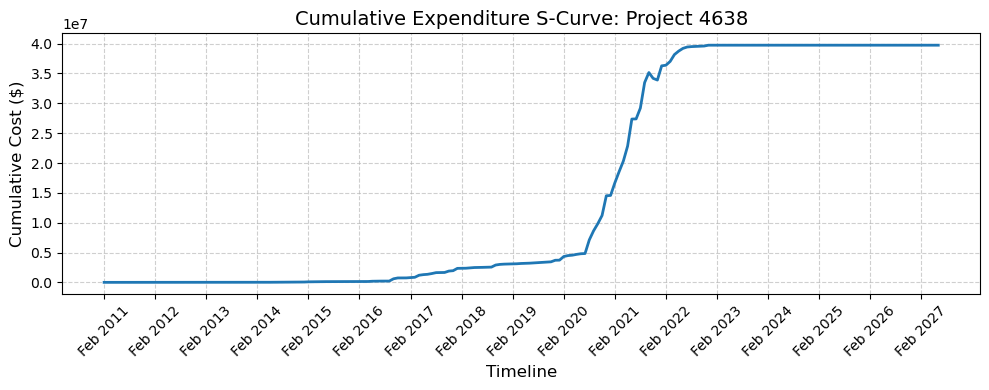

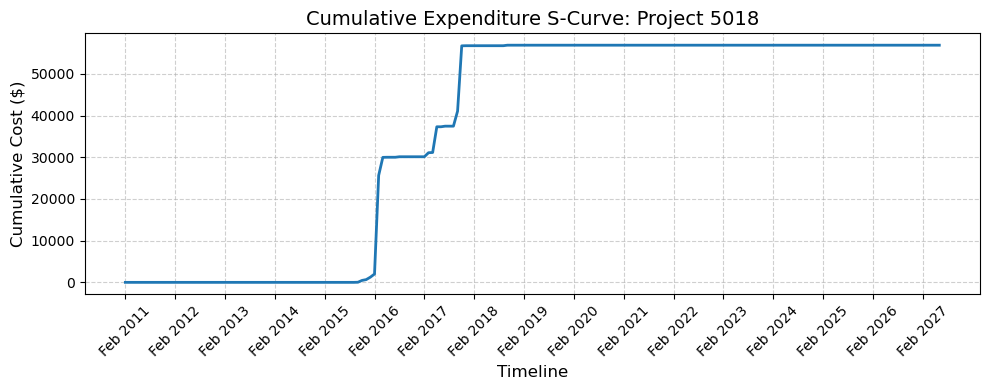

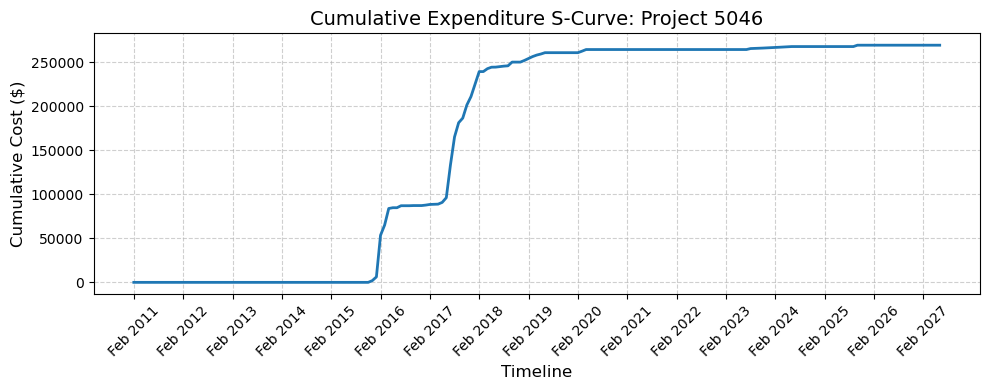

In [11]:
timeline_cols = all_projects_df.columns[5:]

# Plot first 3 S_curves using cumulative sums
for index, row in all_projects_df.head(3).iterrows():
    project_code = row['Project Code']
    cumulative_values = row[timeline_cols]
    plt.figure(figsize=(10, 4))
    plt.plot(timeline_cols, cumulative_values, linewidth=2, color='#1f77b4')
    plt.title(f"Cumulative Expenditure S-Curve: Project {project_code}", fontsize=14)
    plt.xlabel("Timeline", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.xticks(timeline_cols[::12], rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

  [WARN] Project 5538: poor logistic fit R²=0.560, excluding from training labels


,Project Code,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2
40,5538,68,NaN,NaN,NaN,0.559924
5,5105,132,6.647347e+05,0.016684,132.000000,0.777674
45,5558,62,1.860820e+07,0.128090,62.000000,0.800894
23,5471,60,3.522312e+05,0.046087,29.840139,0.829597
35,5528,61,2.358306e+06,0.137051,56.245358,0.844218
86,W5465,74,9.489052e+04,0.025910,71.066254,0.846996
1,5018,37,6.452630e+04,0.113672,15.090819,0.852584
61,5647,49,1.463714e+05,0.234641,13.918210,0.858213
70,5696,19,9.830200e+05,0.163510,13.770493,0.861205
37,5530,63,1.521415e+06,0.060445,63.000000,0.863646


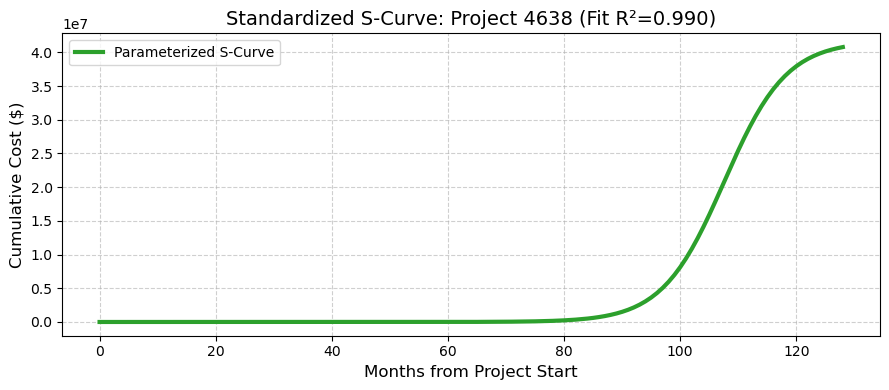

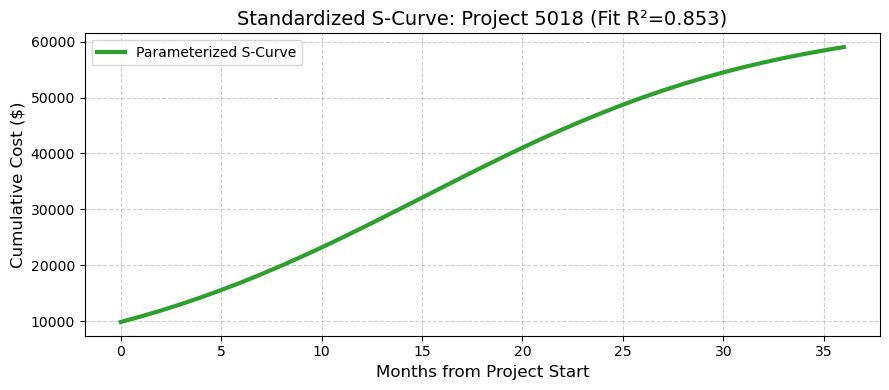

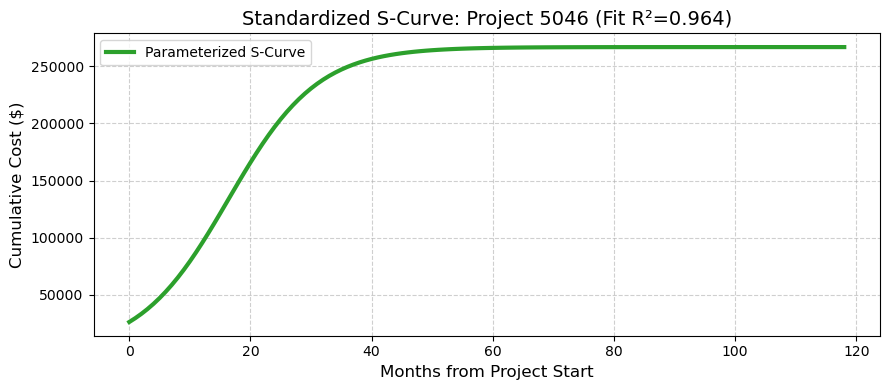

In [12]:
########################################################
"""

Extracts "Duration" (in months), "S_Curve_L" (max value), "S_Curve_k" (growth rate),
"S_Curve_t0" (midpoint) variables from the cumulative monthly spending per month.
All projects "start" in the same arbitrary place. This is what the model will actually
use.

"""
########################################################

# Define our S-curve mathematical model
def logistic_curve(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

all_projects_df_2 = all_projects_df.copy()

# Prepare timeline
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

L_params  = []
k_params  = []
t0_params = []
durations = []
r2_values = []

R2_THRESHOLD = 0.75

# Loop through the projects
for index, row in all_projects_df_2.iterrows():
    y_data_full = row[timeline_cols].values.astype(float)
    start_idx = np.argmax(y_data_full > 0)
    monthly_deltas = np.diff(y_data_full, prepend=0)
    nonzero_months = np.where(monthly_deltas > 0)[0]

    if len(nonzero_months) == 0:
        durations.append(np.nan)
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    stop_idx = nonzero_months[-1]

    # Get duration
    num_months = stop_idx - start_idx + 1
    durations.append(num_months)

    # Filter for projects less than 3 months long
    if num_months < 3:
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    y_active = y_data_full[start_idx : stop_idx + 1]
    x_active = np.arange(num_months)

    # Fit curves
    initial_guess = [y_active[-1], 0.1, num_months / 2]

    max_budget_limit = y_active[-1] * 1.5
    if max_budget_limit == 0:
        max_budget_limit = 1

    param_bounds = ([0, 0.001, 0], [max_budget_limit, 5.0, num_months])

    try:
        popt, pcov = curve_fit(logistic_curve, x_active, y_active, p0=initial_guess, bounds=param_bounds, maxfev=5000)

        # Compute R^2 for fit quality
        y_pred_fit = logistic_curve(x_active, *popt)
        ss_res = np.sum((y_active - y_pred_fit) ** 2)
        ss_tot = np.sum((y_active - np.mean(y_active)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        r2_values.append(r_squared)

        if r_squared < R2_THRESHOLD:
            print(f"  [WARN] Project {row['Project Code']}: poor logistic fit R²={r_squared:.3f}, excluding from training labels")
            L_params.append(np.nan)
            k_params.append(np.nan)
            t0_params.append(np.nan)
        else:
            L_params.append(popt[0])
            k_params.append(popt[1])
            t0_params.append(popt[2])

    except RuntimeError as e:
        print(f"  [FAIL] Project {row['Project Code']}: curve_fit failed — {e}")
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)

# Save features as new columns
all_projects_df_2['Duration_Months'] = durations
all_projects_df_2['S_Curve_L']       = L_params
all_projects_df_2['S_Curve_k']       = k_params
all_projects_df_2['S_Curve_t0']      = t0_params
all_projects_df_2['Fit_R2']          = r2_values

display(all_projects_df_2[['Project Code', 'Duration_Months', 'S_Curve_L', 'S_Curve_k', 'S_Curve_t0', 'Fit_R2']].sort_values('Fit_R2'))

# Plot first 3 valid projects
plotted = 0
for index, row in all_projects_df_2.head(3).iterrows():
    L, k, t0, duration = row['S_Curve_L'], row['S_Curve_k'], row['S_Curve_t0'], row['Duration_Months']
    if pd.isna(L) or pd.isna(k) or pd.isna(t0) or pd.isna(duration):
        continue
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']} (Fit R²={row['Fit_R2']:.3f})", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plotted += 1

In [13]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

# Replace timeline monthly columns with parameters
all_projects_df = all_projects_df_2.drop(columns=timeline_cols, errors='ignore')

In [14]:
# Remove projects with insufficient data (~1-2 months)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "W5678"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5570"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5454"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5538"].reset_index(drop=True)

# Convert feature values to float
all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']] = (
    all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
    .replace({'[\$,]': ''}, regex=True)
    .astype(float)
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.min_rows', 200)
all_projects_df.head(120)

,Project Code,Projected Budget,Projected Commitments,Estimate at Completion,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2
0,4638,4.286000e+07,4.253076e+07,4.286078e+07,129,4.168638e+07,0.186748,107.580953,0.989582
1,5018,1.500000e+05,8.353324e+04,1.738660e+05,37,6.452630e+04,0.113672,15.090819,0.852584
2,5046,3.500000e+05,2.677534e+05,3.643228e+05,119,2.668236e+05,0.135723,16.353815,0.963829
3,5058,5.094500e+08,5.057924e+08,5.095745e+08,67,4.617377e+08,0.197593,38.709869,0.997022
4,5088,1.850000e+08,1.788290e+08,1.853522e+08,67,1.660232e+08,0.200762,47.672112,0.998320
5,5105,4.440000e+05,3.362262e+05,4.440000e+05,132,6.647347e+05,0.016684,132.000000,0.777674
6,5148,4.249000e+08,4.383960e+08,4.265355e+08,120,4.420300e+08,0.139075,98.138408,0.995091
7,5171,5.702750e+08,5.686872e+08,5.710701e+08,107,5.477962e+08,0.101184,82.457031,0.999310
8,5198,1.500000e+06,1.286536e+06,1.500000e+06,92,1.247577e+06,0.075931,17.454996,0.876268
9,5199,5.767000e+06,5.553188e+06,5.767000e+06,95,6.479754e+06,0.060392,56.607492,0.958862


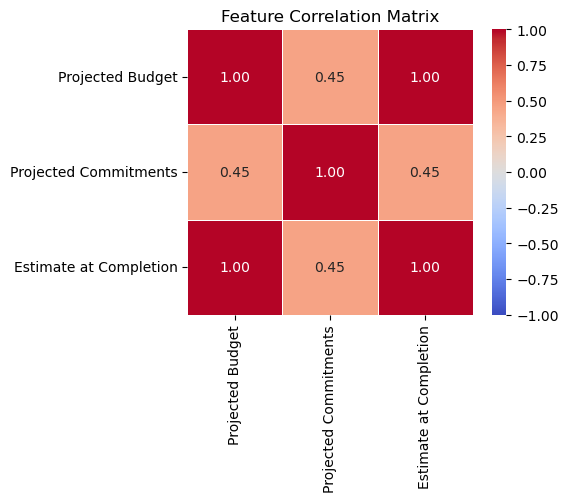

In [15]:
import seaborn as sns

feature_cols = ['Projected Budget', 'Projected Commitments', 'Estimate at Completion']

# Create feature inter-correlation matrix
corr = all_projects_df[feature_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
# Add new features EAC Budget Ratio and Commitments Budget Ratio (financial health independent of project size)
all_projects_df['EAC_Budget_Ratio'] = (all_projects_df['Estimate at Completion'] / all_projects_df['Projected Budget'].replace(0, np.nan))
all_projects_df['Commitments_Budget_Ratio'] = (all_projects_df['Projected Commitments'] / all_projects_df['Projected Budget'].replace(0, np.nan))

# Update feature list
feature_cols = ['Projected Budget', 'Projected Commitments', 'Estimate at Completion', 'EAC_Budget_Ratio', 'Commitments_Budget_Ratio']

pd.set_option('display.max_rows', 200)
pd.set_option('display.min_rows', 200)
display(all_projects_df.head(120))

,Project Code,Projected Budget,Projected Commitments,Estimate at Completion,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2,EAC_Budget_Ratio,Commitments_Budget_Ratio
0,4638,4.286000e+07,4.253076e+07,4.286078e+07,129,4.168638e+07,0.186748,107.580953,0.989582,1.000018,0.992318
1,5018,1.500000e+05,8.353324e+04,1.738660e+05,37,6.452630e+04,0.113672,15.090819,0.852584,1.159107,0.556888
2,5046,3.500000e+05,2.677534e+05,3.643228e+05,119,2.668236e+05,0.135723,16.353815,0.963829,1.040922,0.765010
3,5058,5.094500e+08,5.057924e+08,5.095745e+08,67,4.617377e+08,0.197593,38.709869,0.997022,1.000244,0.992821
4,5088,1.850000e+08,1.788290e+08,1.853522e+08,67,1.660232e+08,0.200762,47.672112,0.998320,1.001904,0.966643
5,5105,4.440000e+05,3.362262e+05,4.440000e+05,132,6.647347e+05,0.016684,132.000000,0.777674,1.000000,0.757266
6,5148,4.249000e+08,4.383960e+08,4.265355e+08,120,4.420300e+08,0.139075,98.138408,0.995091,1.003849,1.031763
7,5171,5.702750e+08,5.686872e+08,5.710701e+08,107,5.477962e+08,0.101184,82.457031,0.999310,1.001394,0.997216
8,5198,1.500000e+06,1.286536e+06,1.500000e+06,92,1.247577e+06,0.075931,17.454996,0.876268,1.000000,0.857691
9,5199,5.767000e+06,5.553188e+06,5.767000e+06,95,6.479754e+06,0.060392,56.607492,0.958862,1.000000,0.962925


In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [18]:
########################################################
"""

LOO CROSS-VALIDATION FOR EACH TARGET: Duration_Months, S_Curve_L, S_Curve_k, S_Curve_t0
GridSearchCV finds best RF hyperparameters once on the full dataset, cross_val_predict
then generates out-of-fold predictions via LOO. 

Trains both a RandomForest and GradientBoostingRegressor and takes the better of the 2.

"""
########################################################

X = all_projects_df[feature_cols]
targets = {'Duration_Months': all_projects_df['Duration_Months'], 'S_Curve_L': all_projects_df['S_Curve_L'], 'S_Curve_k': all_projects_df['S_Curve_k'], 'S_Curve_t0': all_projects_df['S_Curve_t0']}

loo = LeaveOneOut()
best_models    = {}
loo_predictions = {}

param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf':  [1, 2, 4], 'max_features':    ['sqrt', 'log2', 1.0]}

for target_name, y in targets.items():
    print(f"\n{'='*55}")
    print(f"  TARGET: {target_name}")
    print(f"{'='*55}")

    # Random Forest
    print("\n[Random Forest]")
    gs = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X, y)
    best_rf = gs.best_estimator_
    print(f"  Best params: {gs.best_params_}")

    y_pred_rf = cross_val_predict(best_rf, X, y, cv=loo)
    rf_rmse = np.sqrt(mean_squared_error(y, y_pred_rf))
    rf_mae  = mean_absolute_error(y, y_pred_rf)
    rf_r2   = r2_score(y, y_pred_rf)
    print(f"  LOO RMSE: {rf_rmse:.4f}  |  MAE: {rf_mae:.4f}  |  R²: {rf_r2:.4f}")

    # Feature importance for RF
    best_rf.fit(X, y)
    importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()

    # Gradient Boosting
    print("\n[Gradient Boosting]")
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, min_samples_leaf=2)
    y_pred_gb = cross_val_predict(gb, X, y, cv=loo)
    gb_rmse = np.sqrt(mean_squared_error(y, y_pred_gb))
    gb_r2   = r2_score(y, y_pred_gb)
    print(f"  LOO RMSE: {gb_rmse:.4f}  |  R²: {gb_r2:.4f}")

    # Use the better model
    if gb_r2 > rf_r2:
        print(f"  -> GBR wins (R² {gb_r2:.4f} vs RF {rf_r2:.4f})")
        gb.fit(X, y)
        best_models[target_name]    = gb
        loo_predictions[target_name] = y_pred_gb
    else:
        print(f"  -> RF wins (R² {rf_r2:.4f} vs GBR {gb_r2:.4f})")
        best_models[target_name]    = best_rf   # already refit above
        loo_predictions[target_name] = y_pred_rf

predictions1 = loo_predictions['Duration_Months']
predictions2 = loo_predictions['S_Curve_L']
predictions3 = loo_predictions['S_Curve_k']
predictions4 = loo_predictions['S_Curve_t0']


  TARGET: Duration_Months

[Random Forest]
  Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  LOO RMSE: 26.7599  |  MAE: 19.7415  |  R²: 0.1989

[Gradient Boosting]
  LOO RMSE: 25.7428  |  R²: 0.2587
  -> GBR wins (R² 0.2587 vs RF 0.1989)

  TARGET: S_Curve_L

[Random Forest]
  Best params: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  LOO RMSE: 22845192.5299  |  MAE: 7978419.2237  |  R²: 0.9643

[Gradient Boosting]
  LOO RMSE: 22586203.9540  |  R²: 0.9651
  -> GBR wins (R² 0.9651 vs RF 0.9643)

  TARGET: S_Curve_k

[Random Forest]
  Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
  LOO RMSE: 0.5364  |  MAE: 0.2199  |  R²: -0.0507

[Gradient Boosting]
  LOO RMSE: 0.6311  |  R²: -0.4543
  -> RF wins (R² -0.0507 vs GBR -0.4543)

  TARGET: S_Curve_t0

[Random Forest]
  Best par

### TRIAL 1 LOO RMSEs:
Duration: 25.3167 |
Max Value: 22561999.9793 |
Growth Rate: 0.5321 |
Midpoint: 22.1840

### TRIAL 2 LOO RMSEs:
Duration: 25.3017 |
Max Value: 22635005.0392 |
Growth Rate: 0.5410 |
Midpoint: 22.6345

### TRIAL 3 LOO RMSEs:
Duration: 25.7428 |
Max Value: 22586203.9540 |
Growth Rate: 0.5364 |
Midpoint: 22.5609

*(max value RMSE is, even relatively, really bad but this doesn't matter - we won't use this in the actual curve plots)*
***

With train/test/split Random State 99 = predicting on indices: 25, 36, 29, 22, 28, 31, 26, 13
Which are project codes: 5540, 5659, 5570, 5530, 5566, 5583, 5551, 5456



In [22]:
# Build predictions DataFrame
predictions_df = pd.DataFrame({
    "Project Code": all_projects_df['Project Code'].values,
    "Duration_Months": predictions1, "S_Curve_L": predictions2, "S_Curve_k": predictions3, "S_Curve_t0": predictions4
    })

# Replace "S_Curve_L" predictions with "Projected Commitments" data
predictions_df["S_Curve_L"] = all_projects_df["Projected Commitments"]

print("Predictions DataFrame (LOO out-of-fold, all projects):")

pd.set_option('display.max_rows', 200)
pd.set_option('display.min_rows', 200)
display(predictions_df)

Predictions DataFrame (LOO out-of-fold, all projects):


,Project Code,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0
0,4638,56.728624,4.253076e+07,0.213540,38.606177
1,5018,45.017341,8.353324e+04,0.180774,27.503144
2,5046,92.694652,2.677534e+05,0.156652,33.231284
3,5058,116.930917,5.057924e+08,0.178189,65.892475
4,5088,53.036459,1.788290e+08,0.180367,56.036944
5,5105,86.094478,3.362262e+05,0.290179,22.220619
6,5148,75.227174,4.383960e+08,0.239288,56.161266
7,5171,81.320747,5.686872e+08,0.222881,56.957626
8,5198,44.441259,1.286536e+06,0.320182,35.768350
9,5199,119.484115,5.553188e+06,0.244368,38.703321


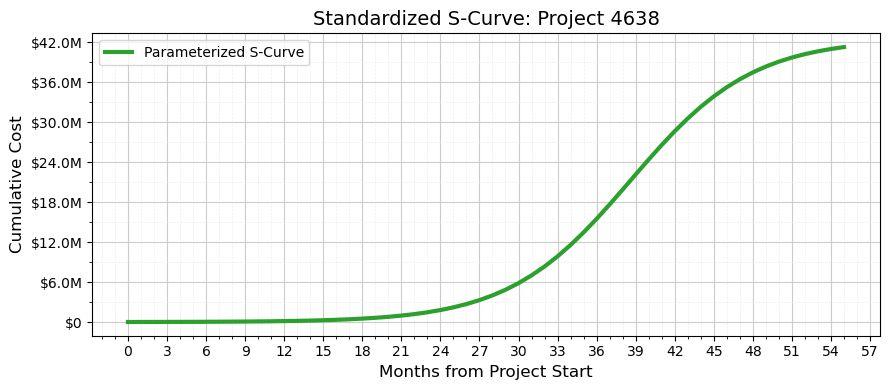

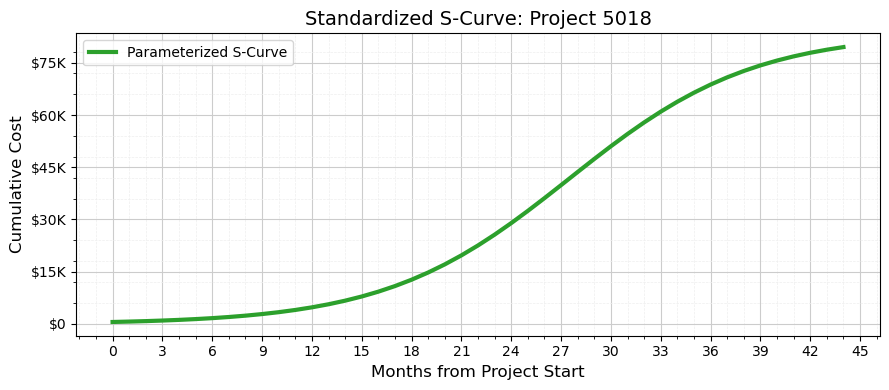

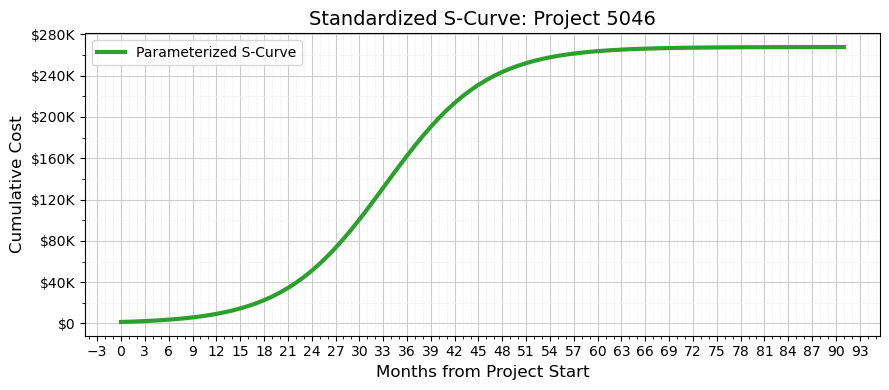

In [23]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Define the currency formatter function before the loop
def format_currency(x, pos):
    """Formats large numbers into readable currency (e.g., $1.5M or $500K)"""
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    else:
        return f'${x:,.0f}'

# Loop through and plot projects
for index, row in predictions_df.head(3).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    duration = row['Duration_Months']
    
    # Generate X axis
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    
    # Plot the curve
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12) 
    plt.ylabel("Cumulative Cost", fontsize=12) # Removed ($) since the formatter adds it
    
    ax = plt.gca() 
    
    # X-Axis: Major ticks every 3 months, minor ticks every 1 month
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    # Y-Axis: Format as currency, create ~8 even major tick slices
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.yaxis.set_major_locator(plt.MaxNLocator(8)) 
    ax.yaxis.set_minor_locator(plt.MaxNLocator(16)) 
    
    # Update grid to show both major (solid) and minor (dashed) lines
    plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

RESULT: Curves are fairly accurate! Duration is not too bad either!

Cumulative cost figures only are wayyy off. (culprit is S_Curve_L)

### NEXT THINGS TO TRY:
- Try a version (make a fresh copy of the book) with only cost data (no sq footage): -> PROS: MORE data, maybe more focused, CONS: less user input (loss of a key feature)

- Use the "Projected Budget" input to replace "Cumulative Cost" (makes sense... this is a better indicator than whatever the model could produce anyway)

- Use models to write a simple script where the user does the inputs (either with gross sq footage or without) and the S-Curve is created

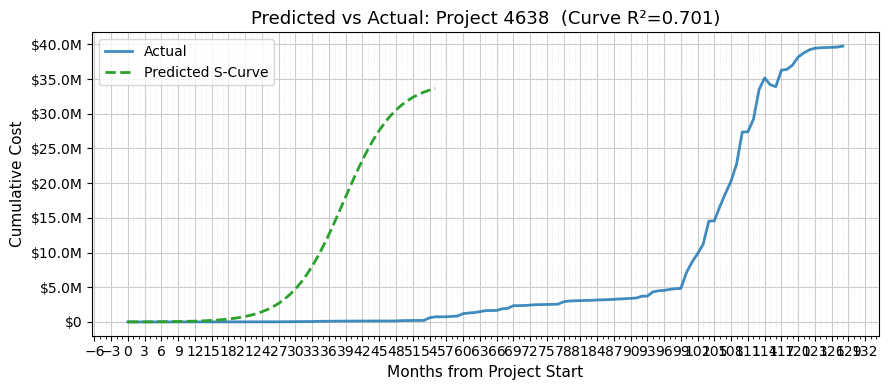

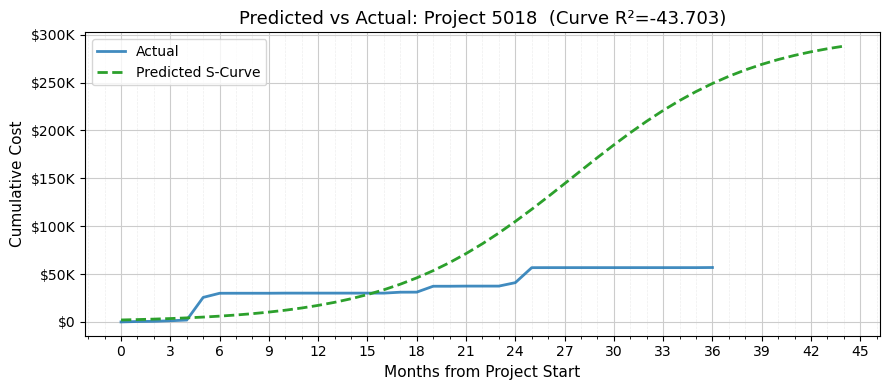

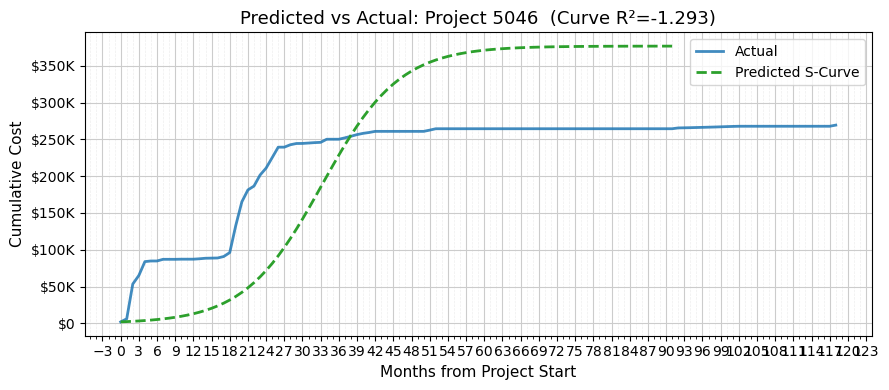

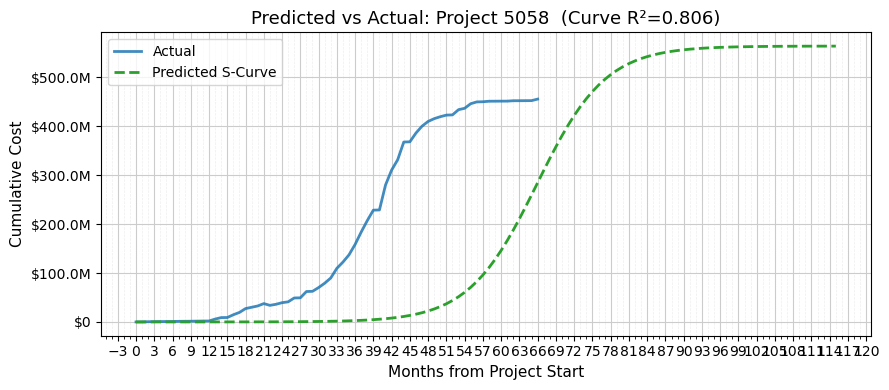

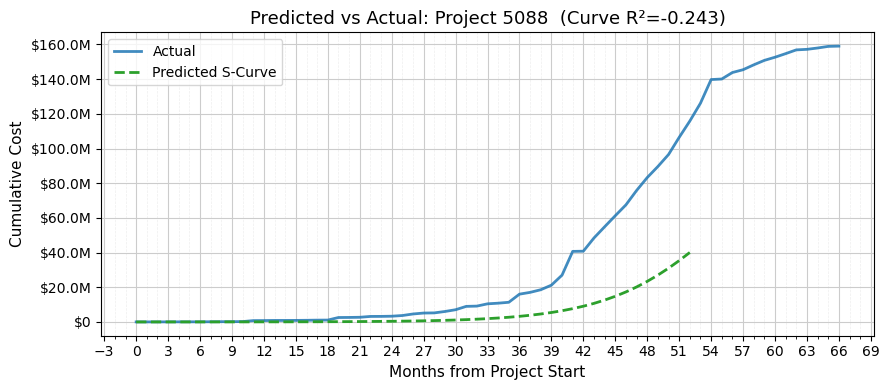

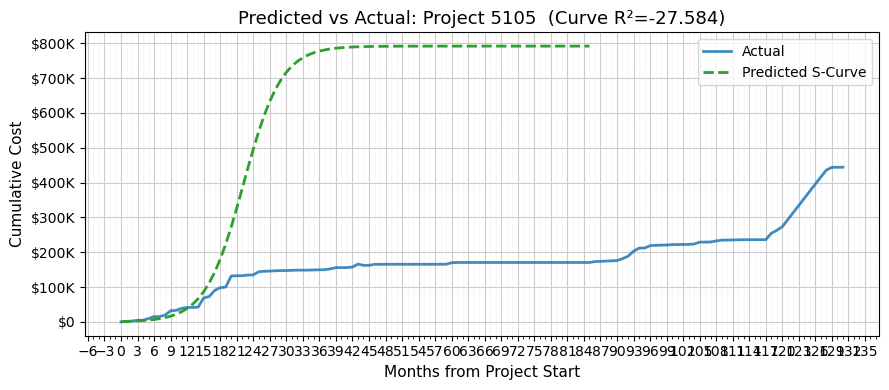

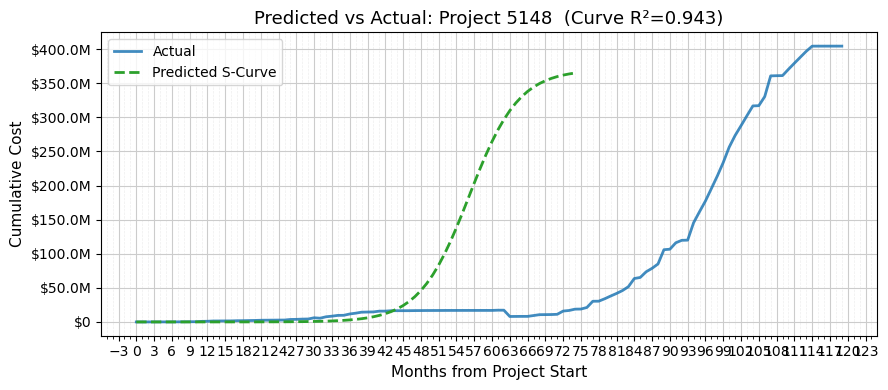

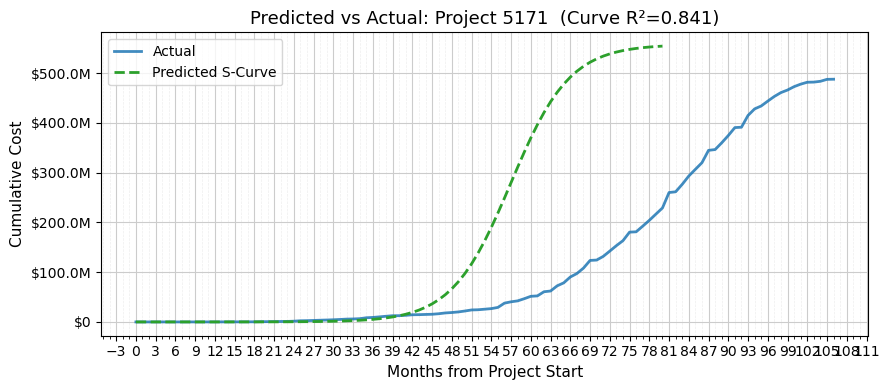

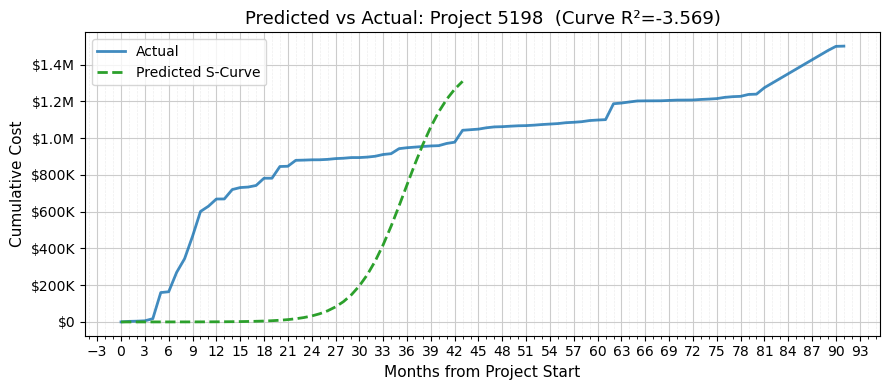

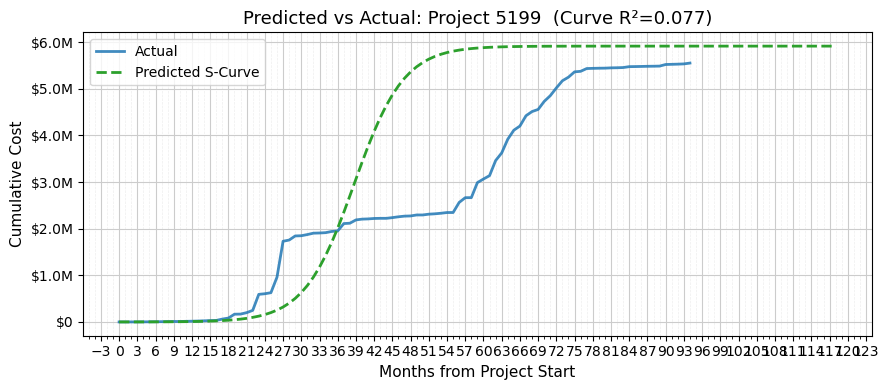

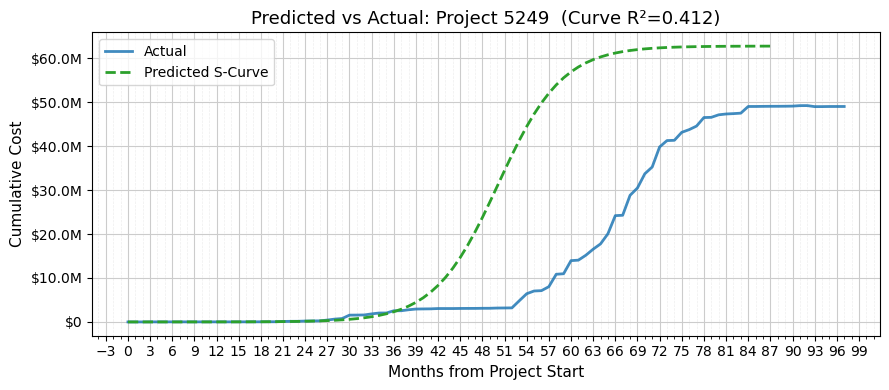

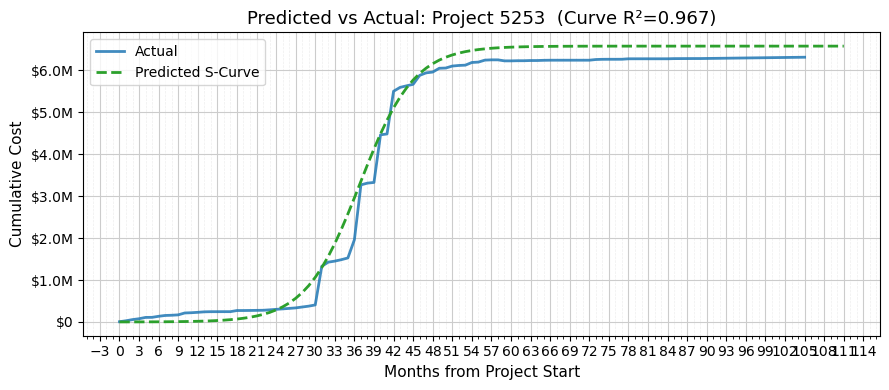

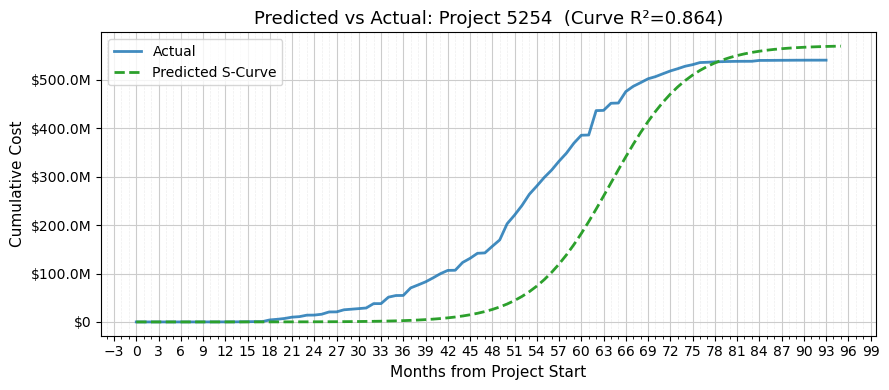

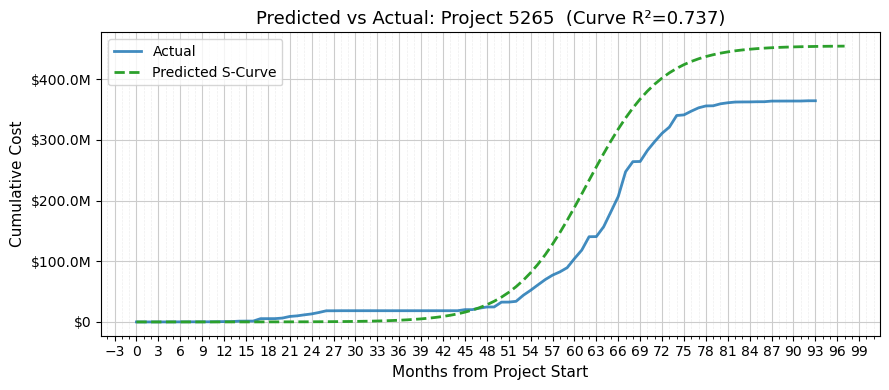

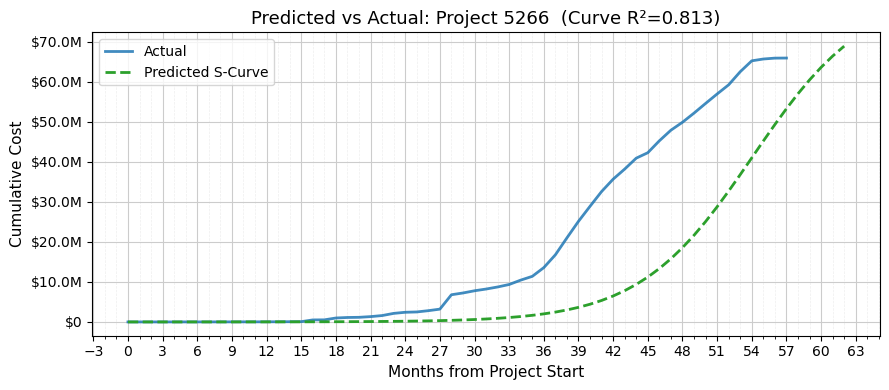

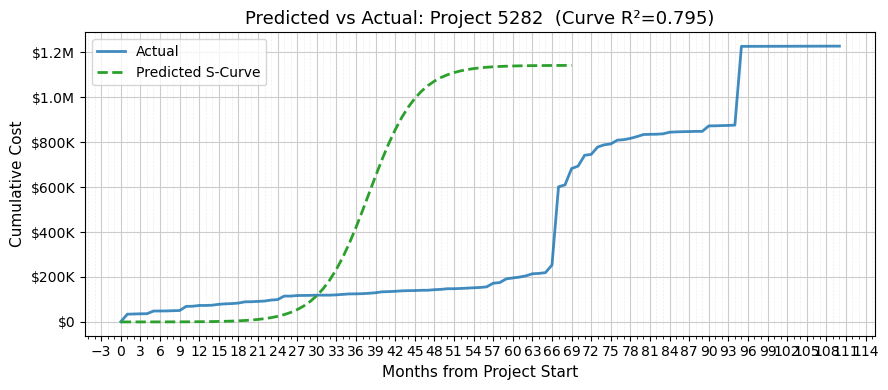

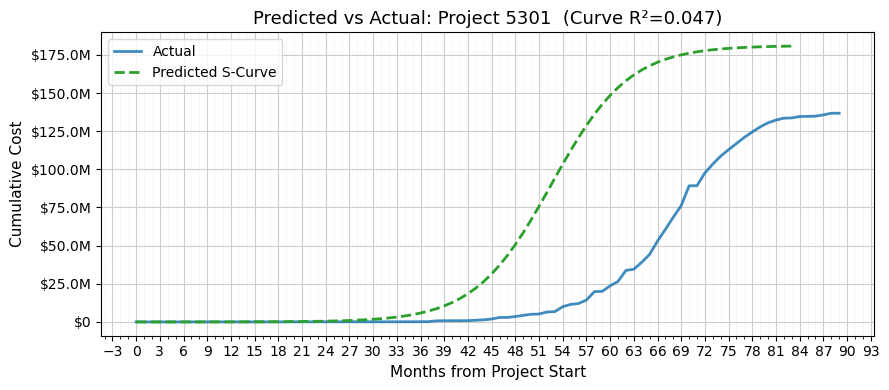

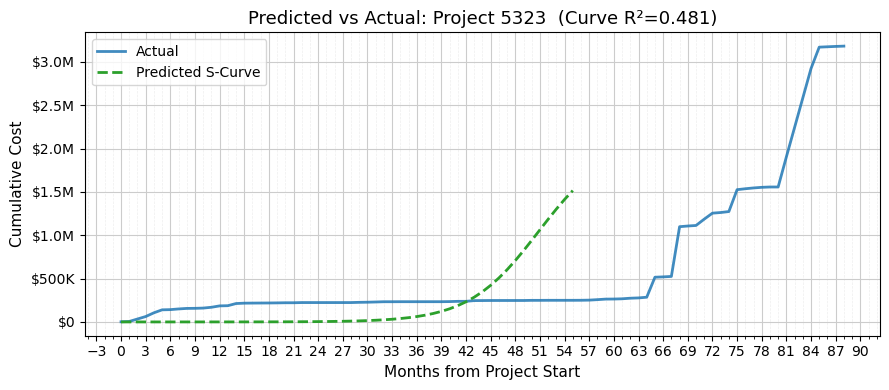

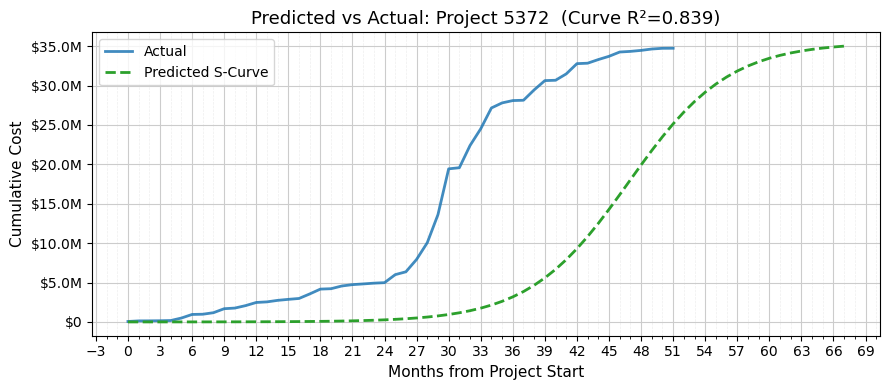

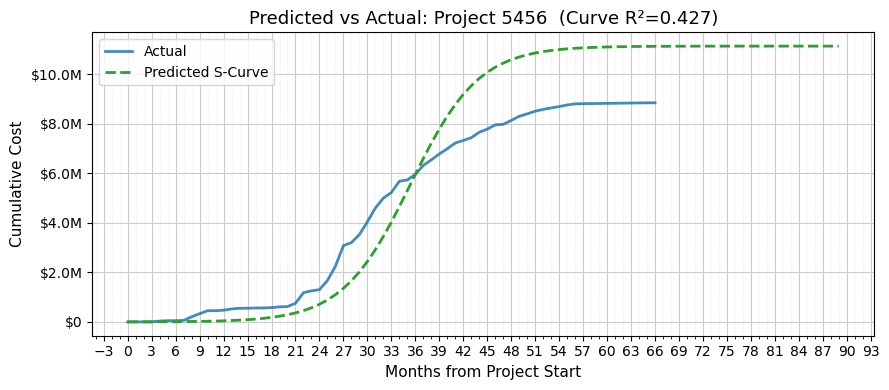

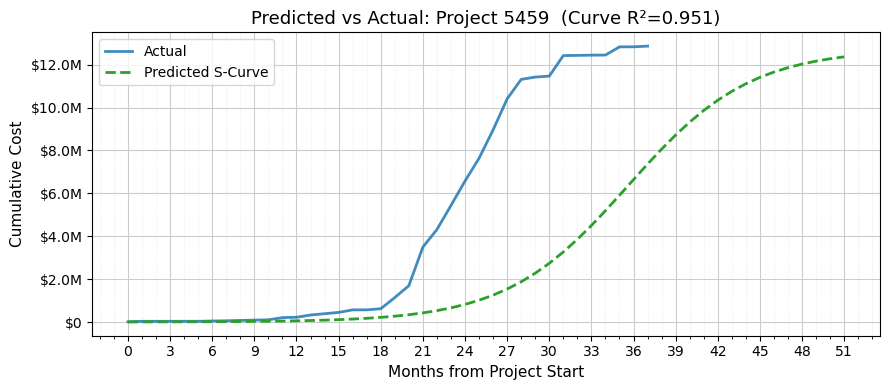

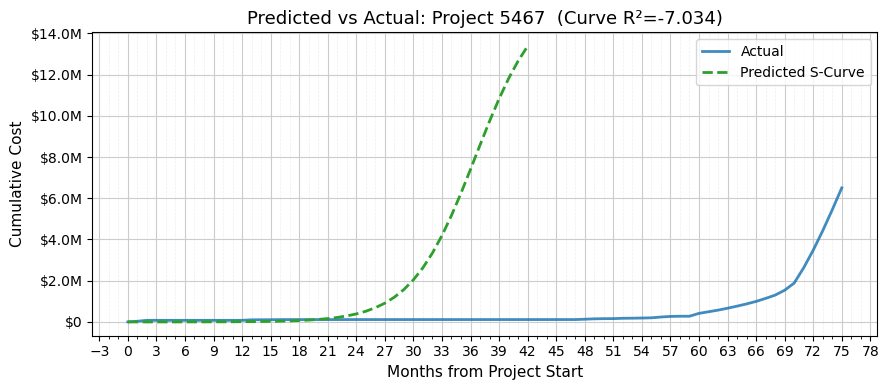

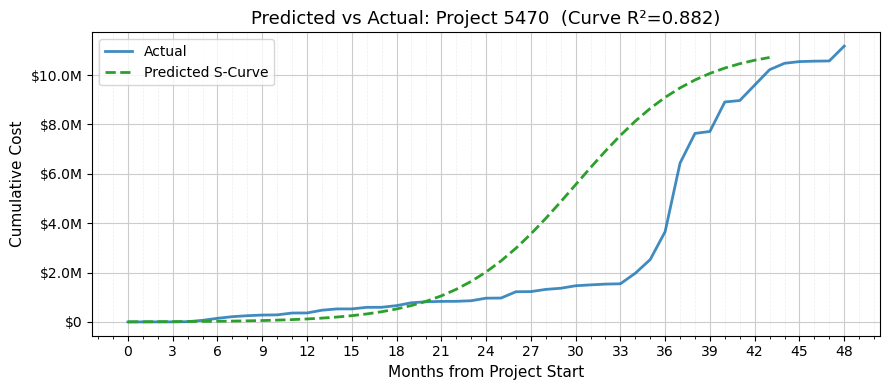

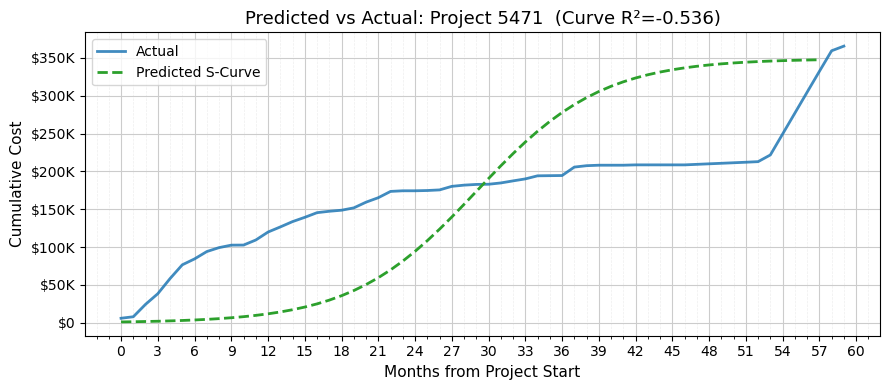

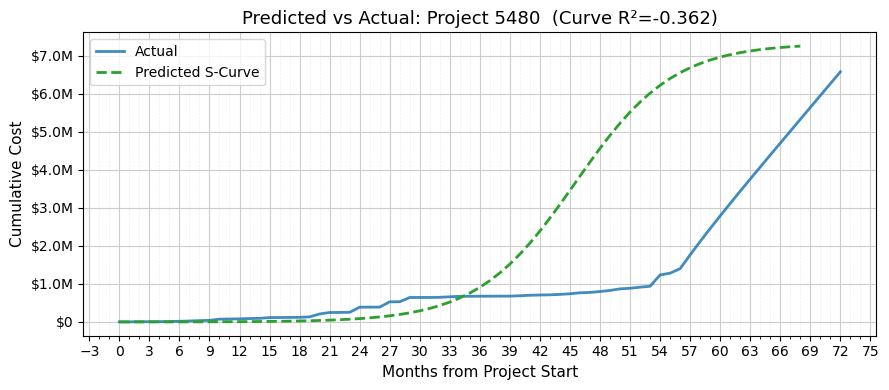

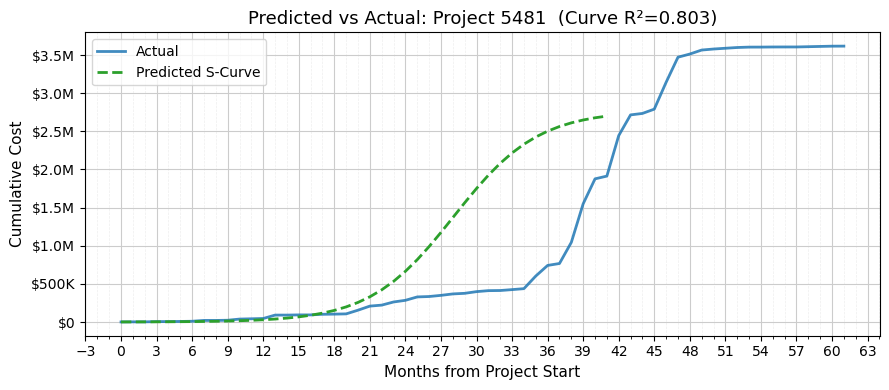

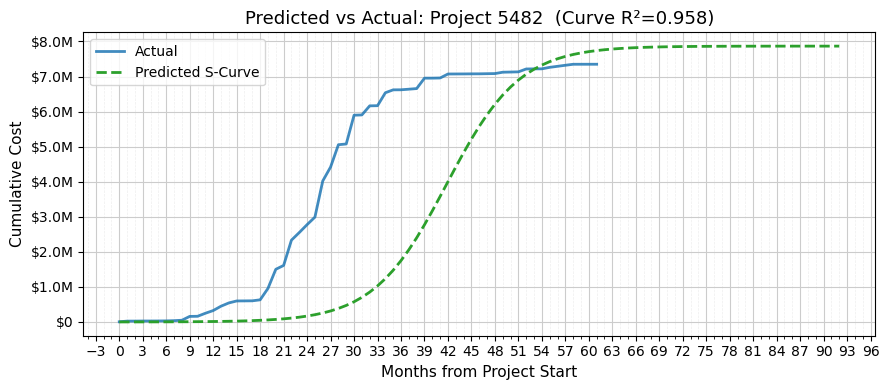

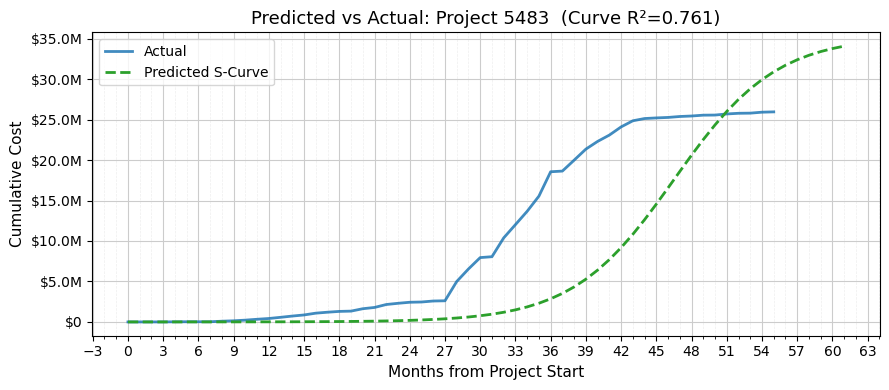

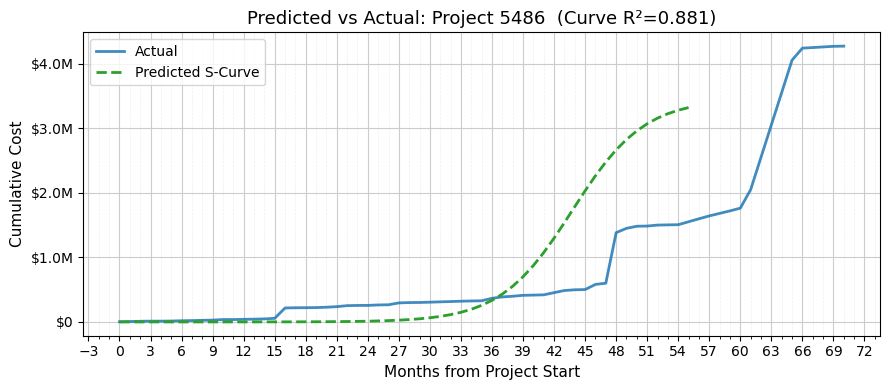

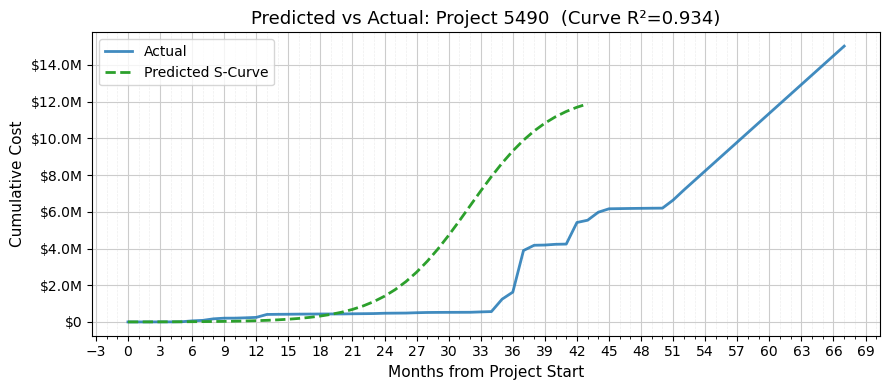

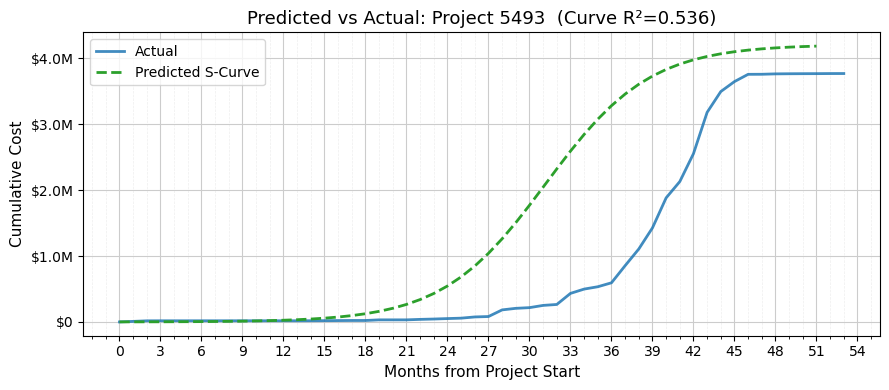

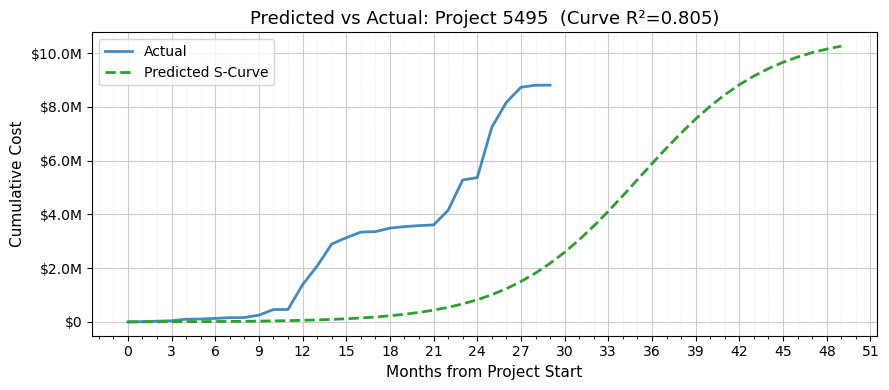

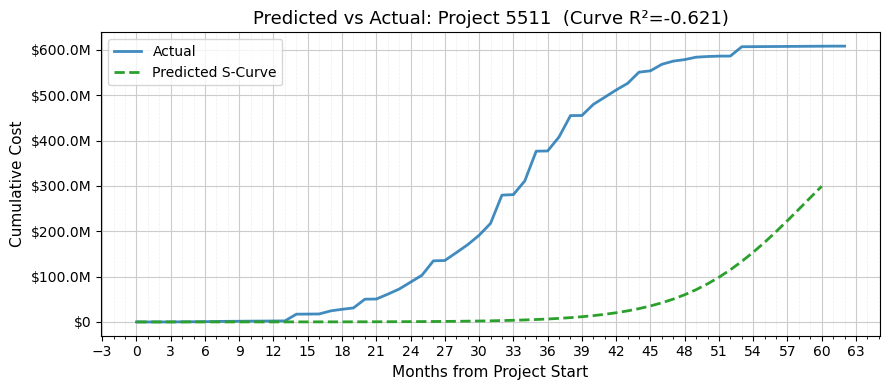

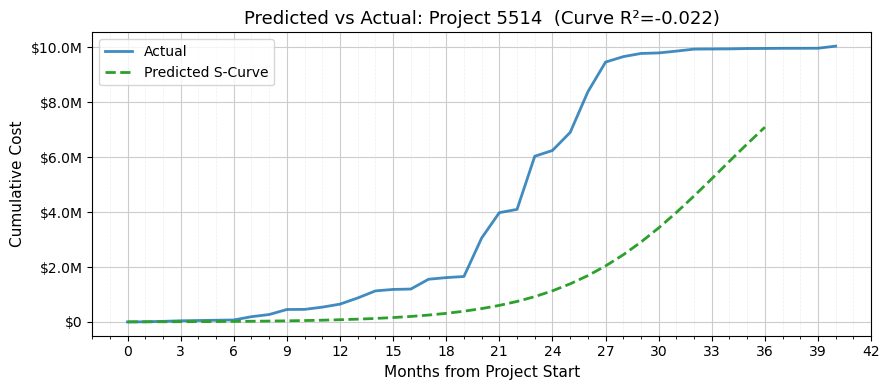

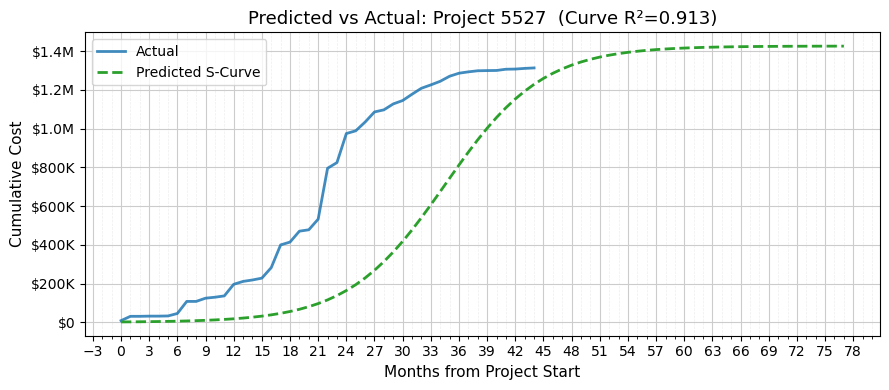

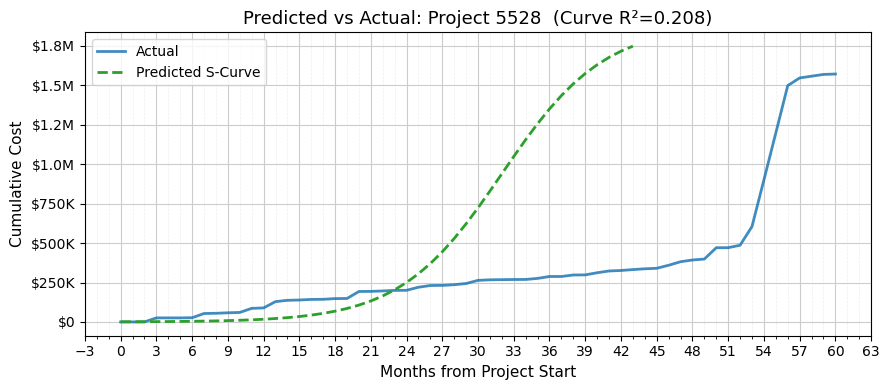

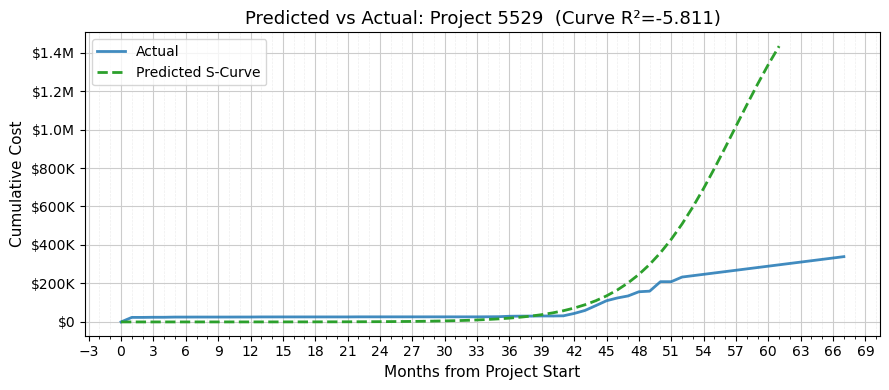

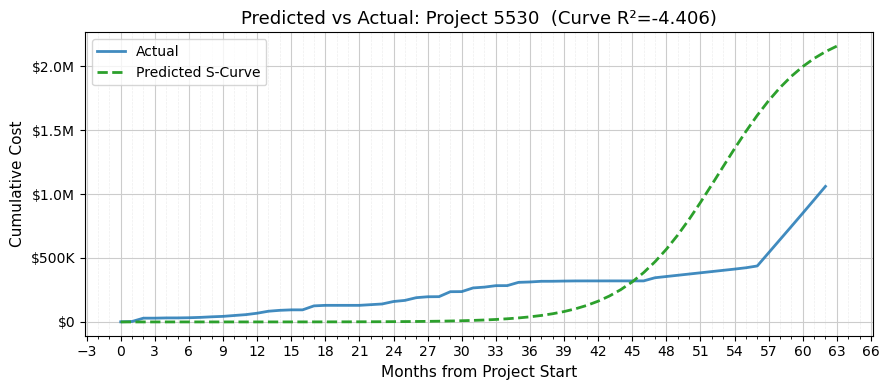

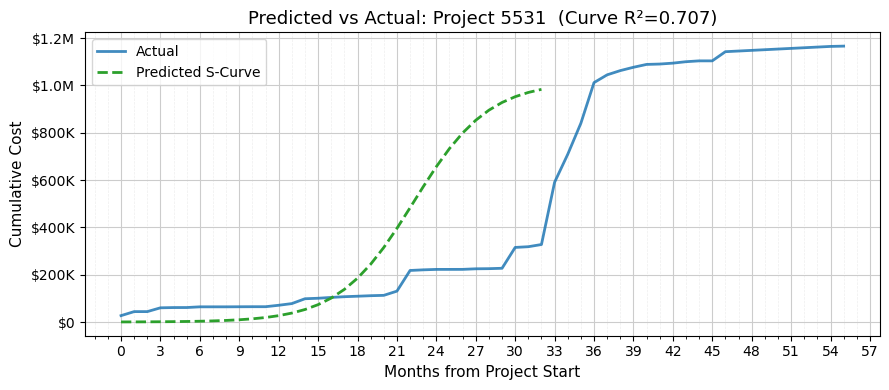

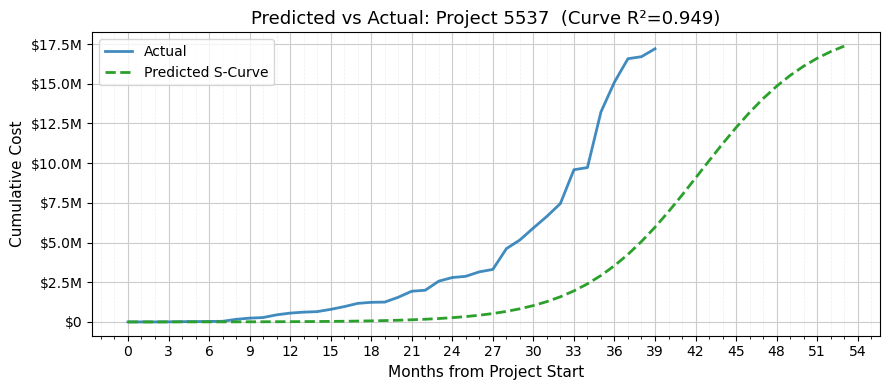

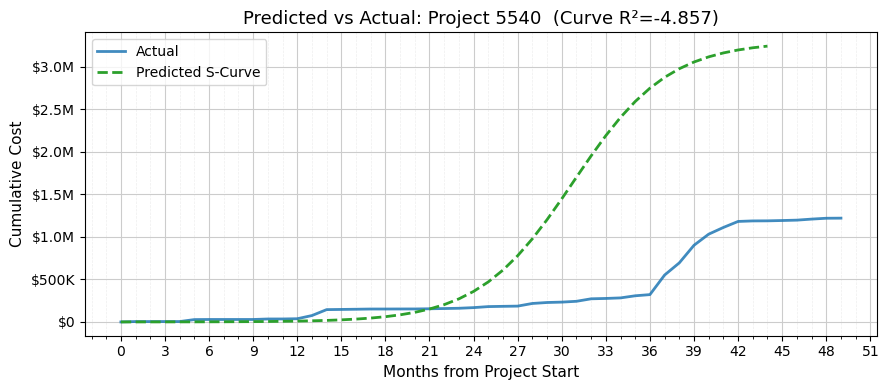

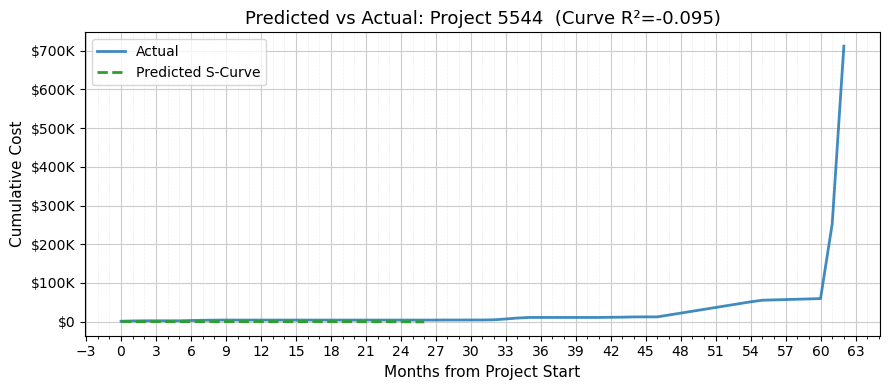

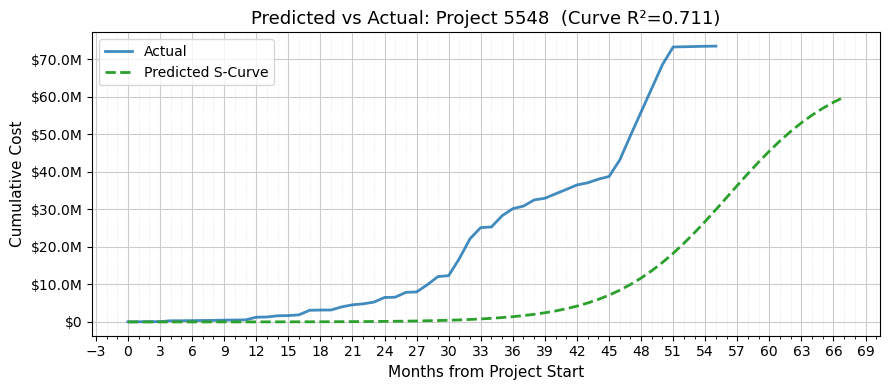

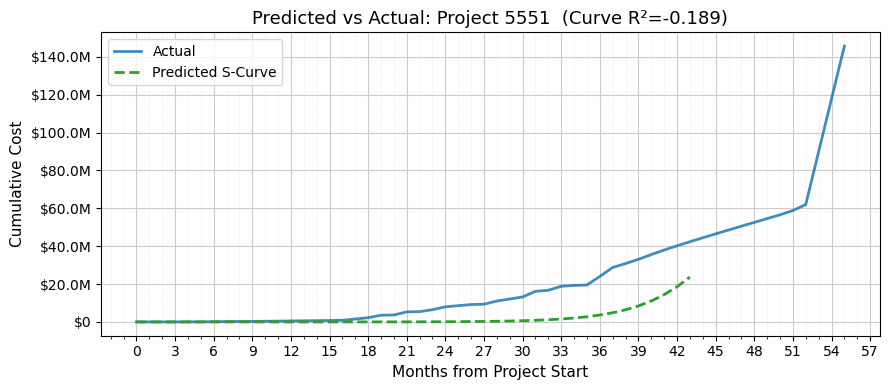

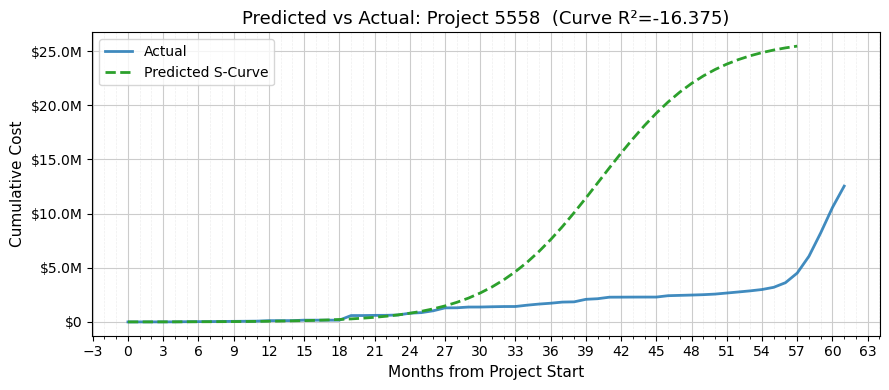

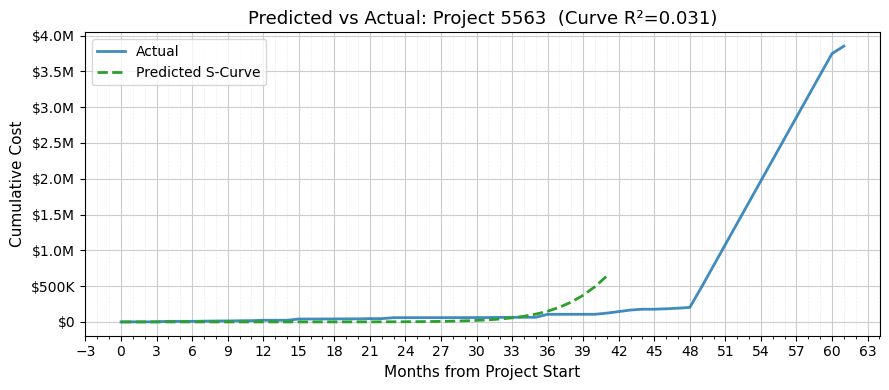

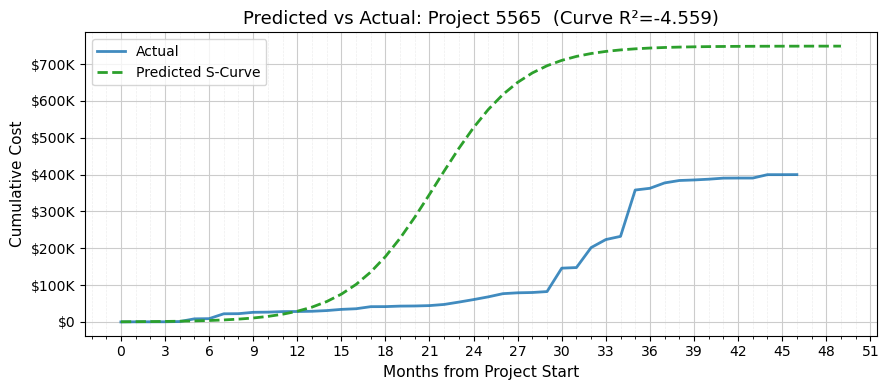

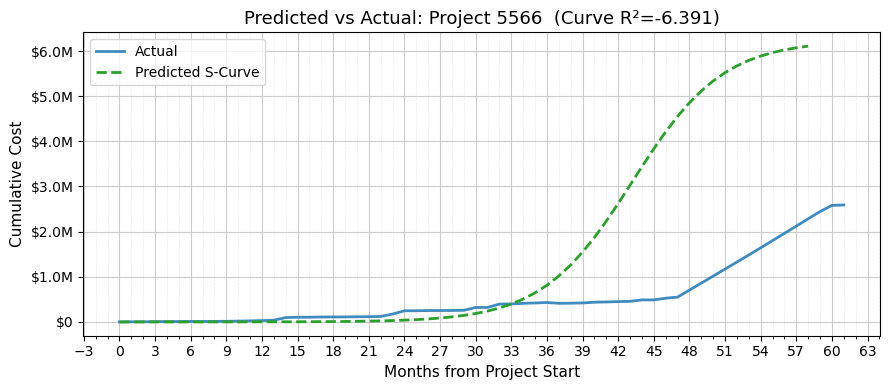

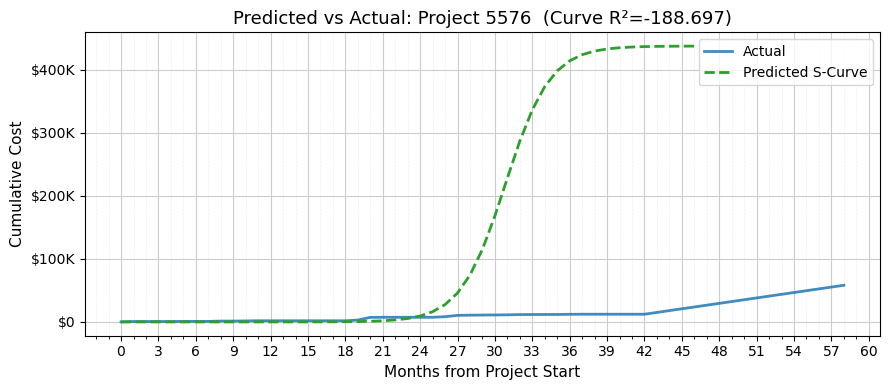

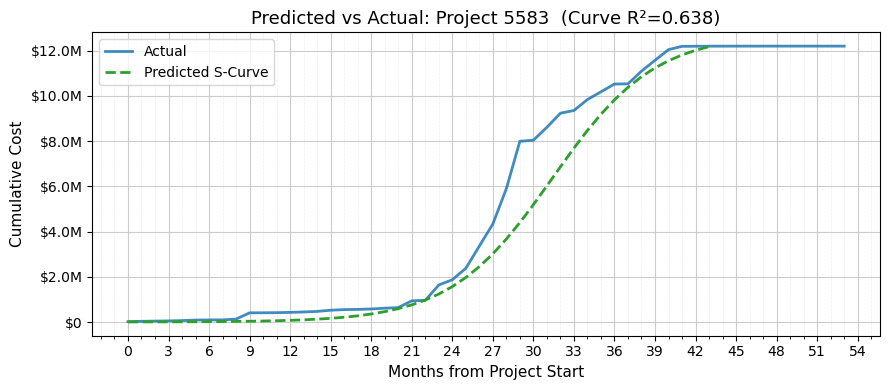

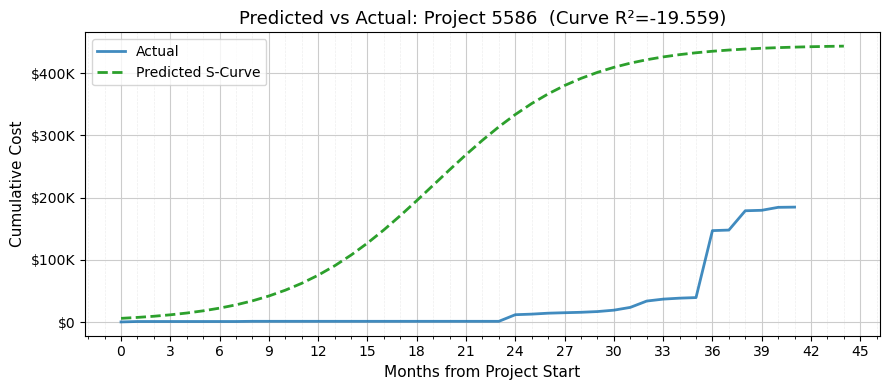

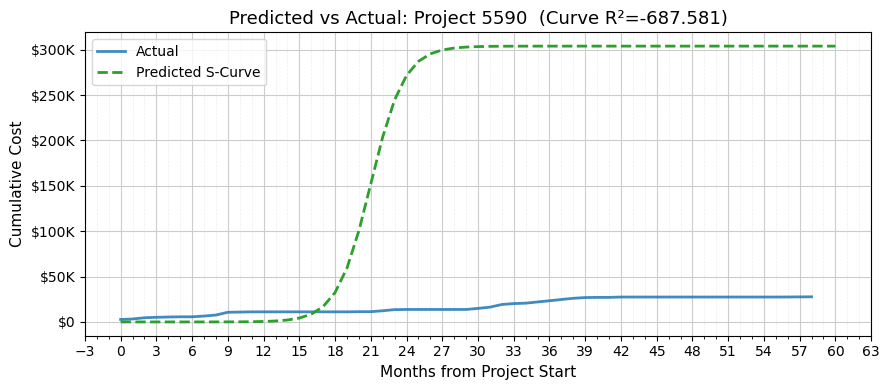

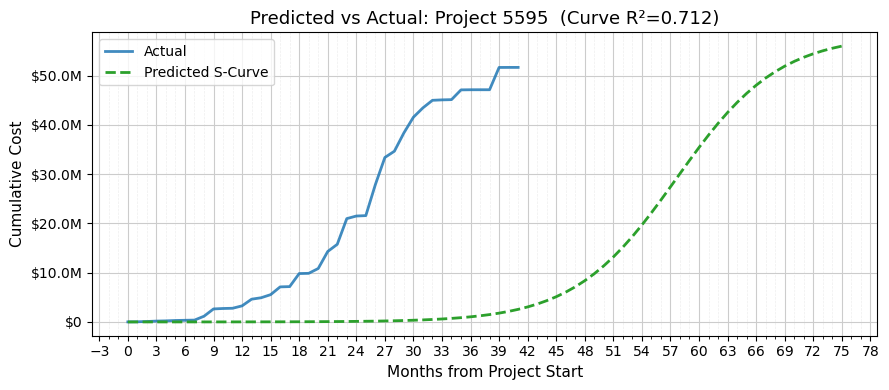

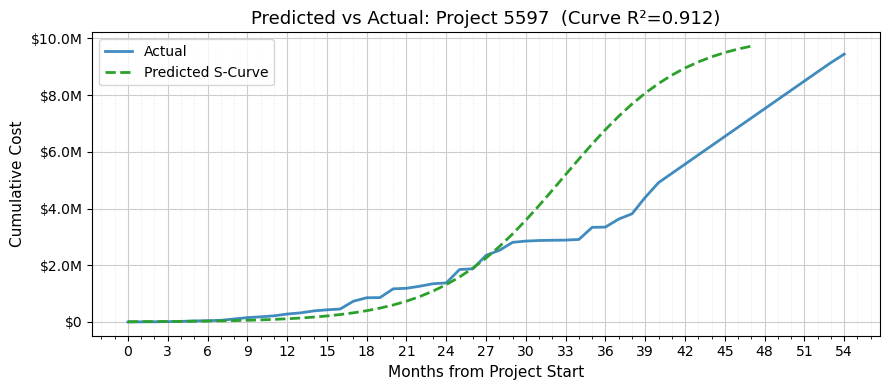

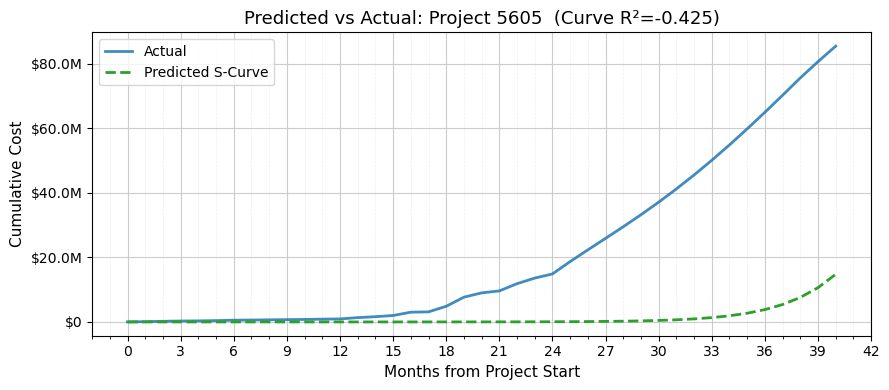

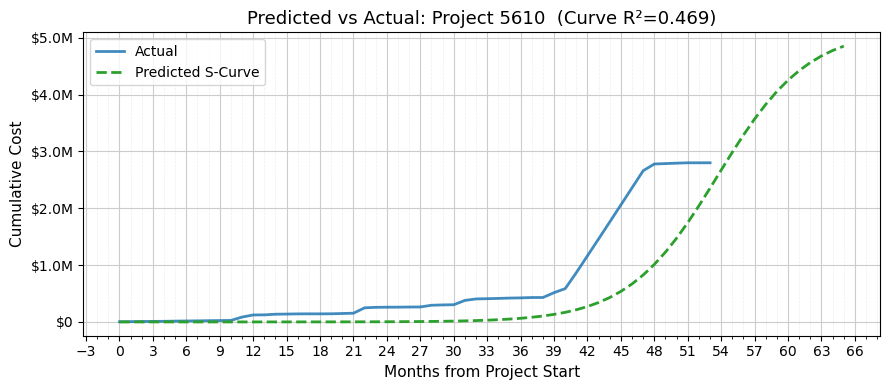

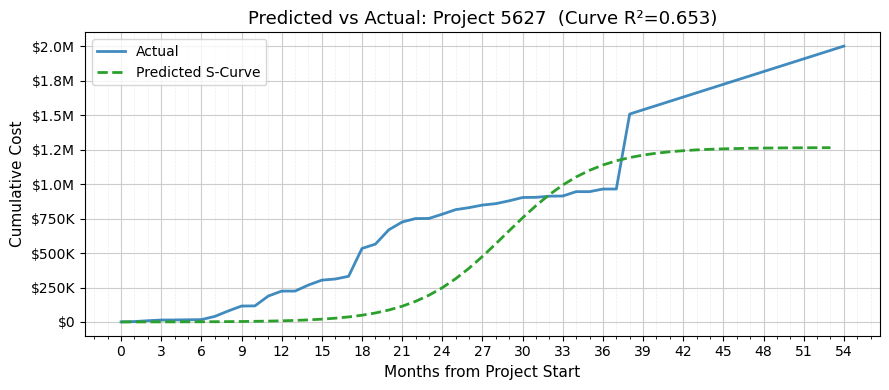

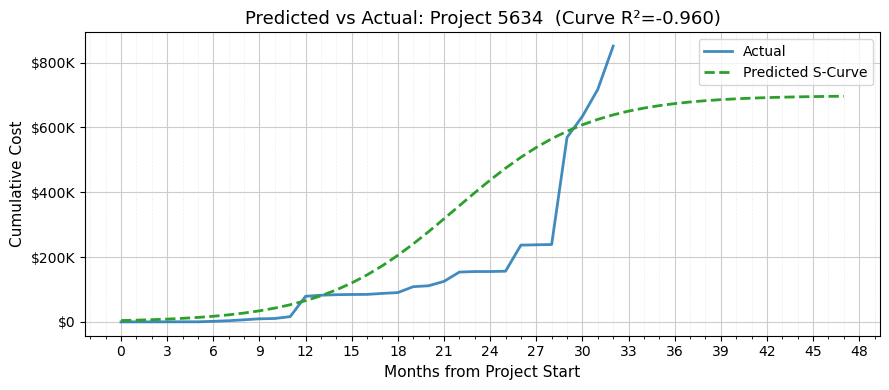

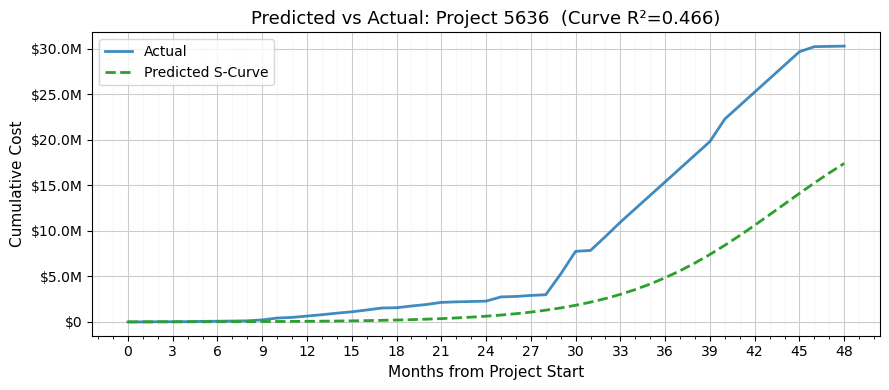

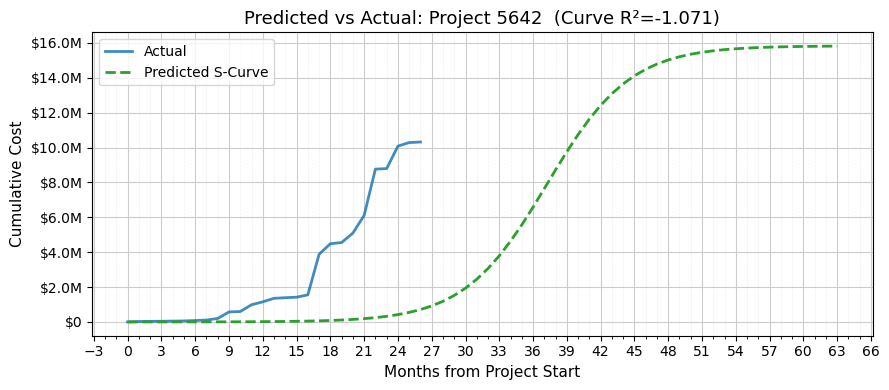

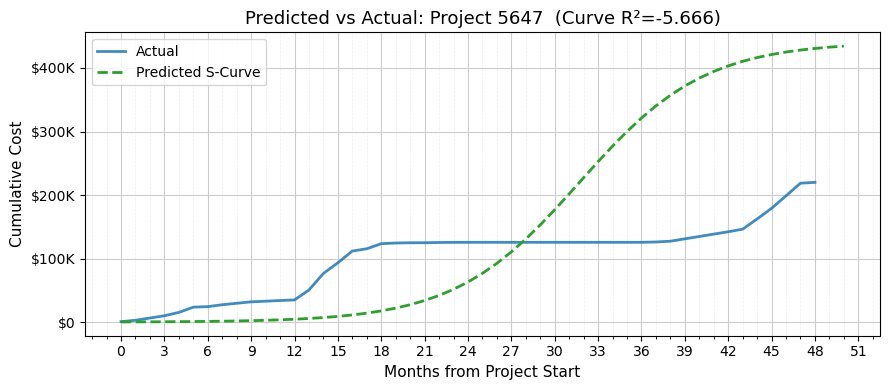

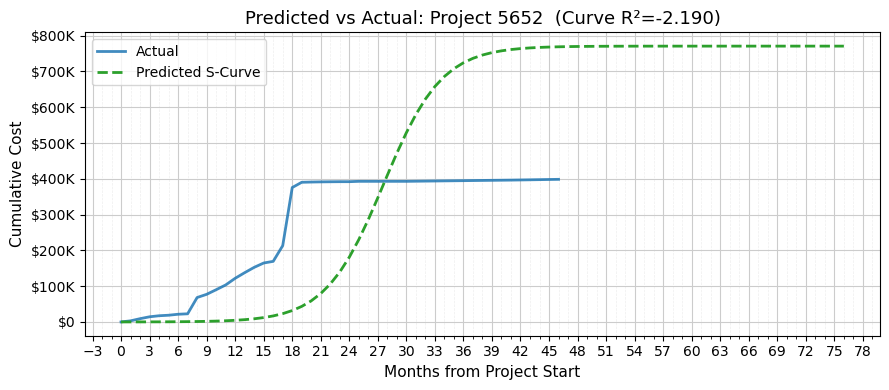

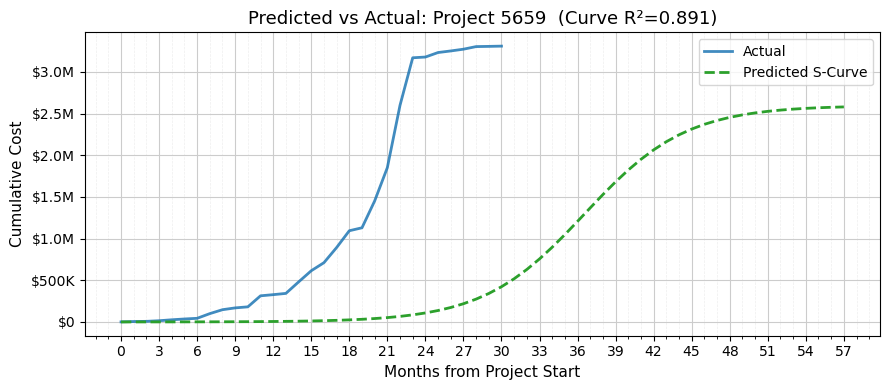

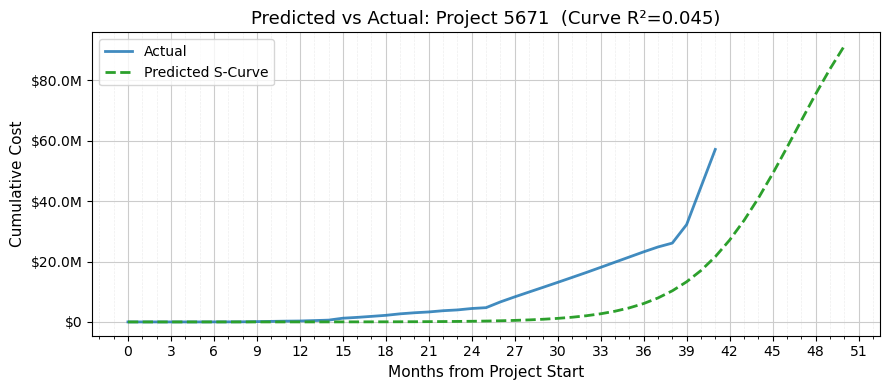

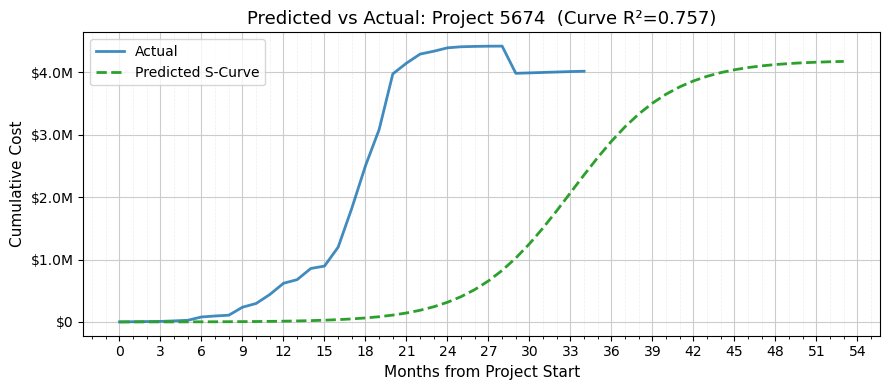

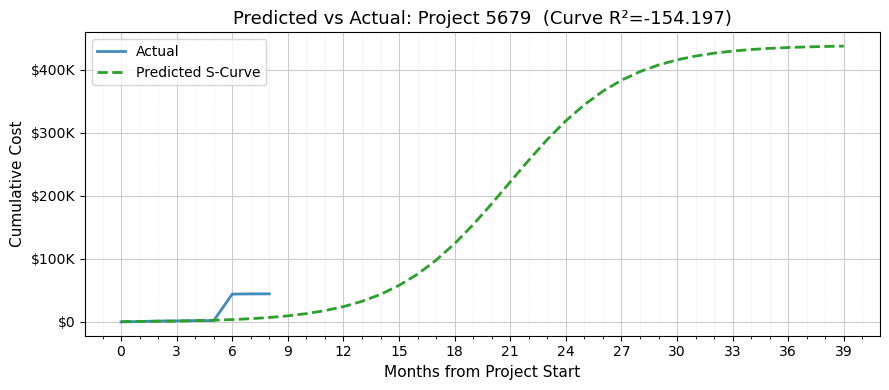

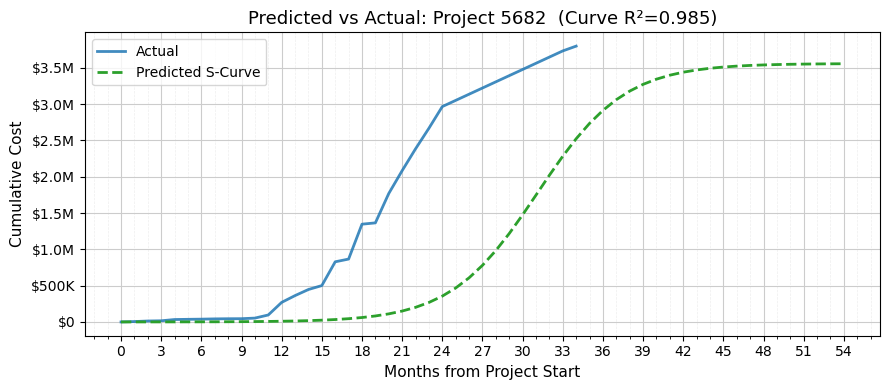

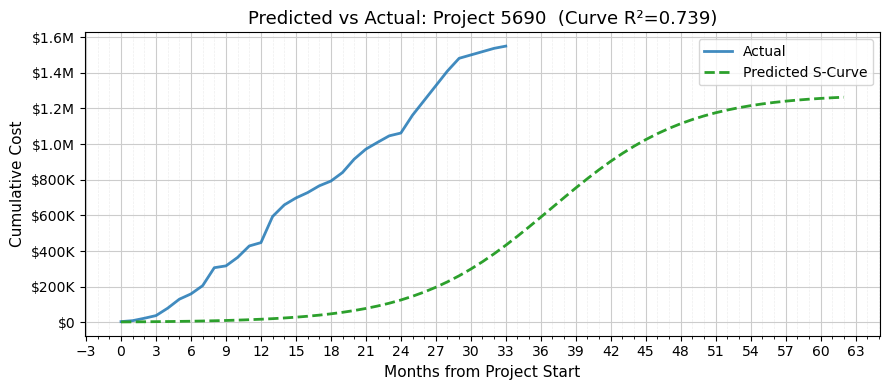

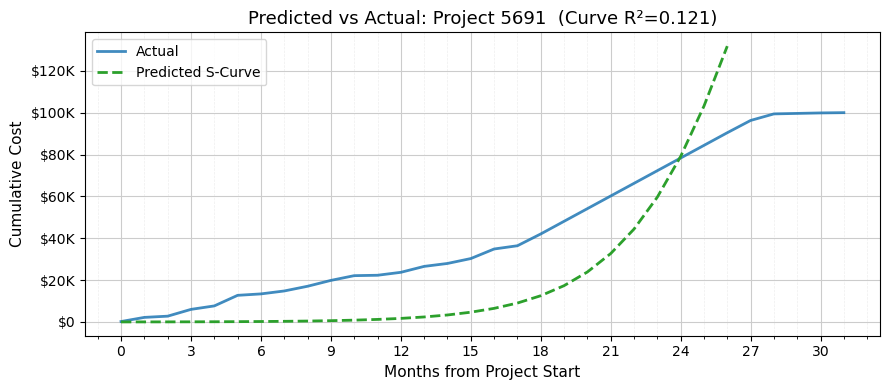

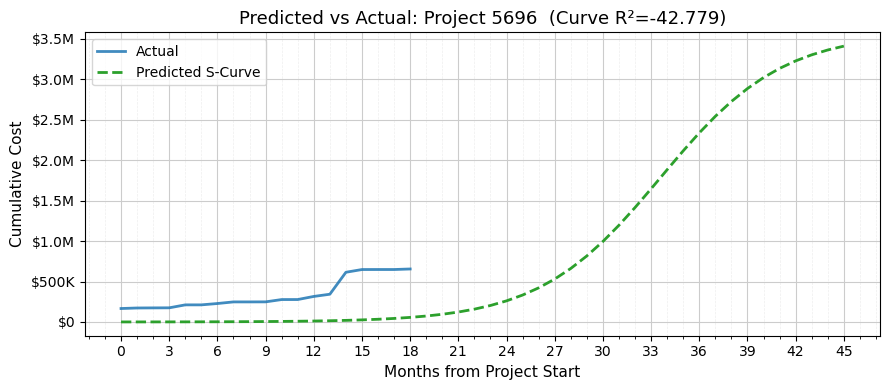

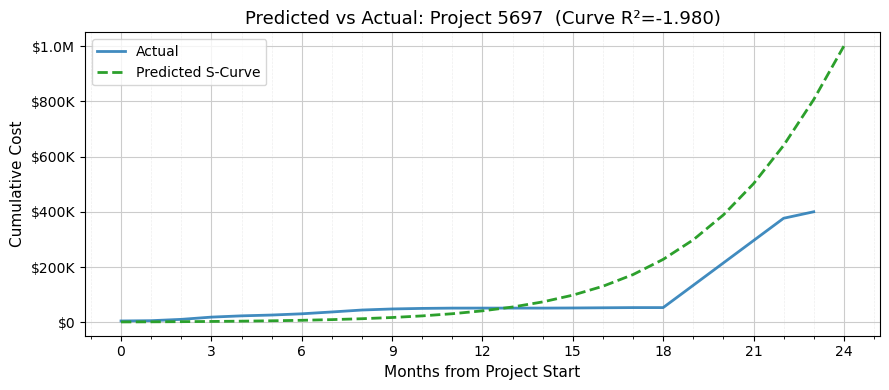

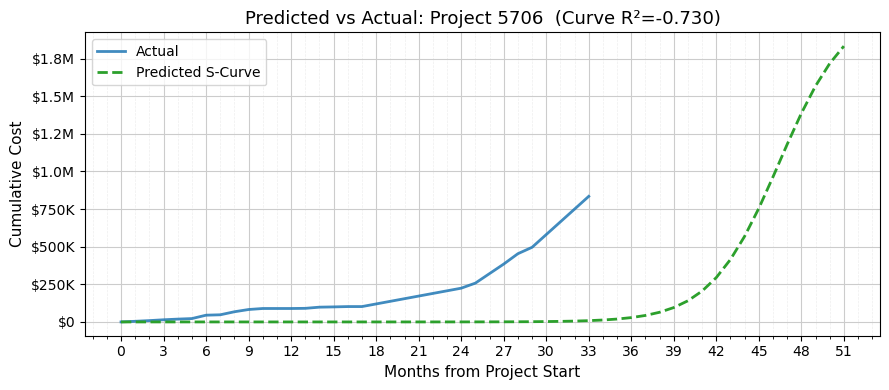

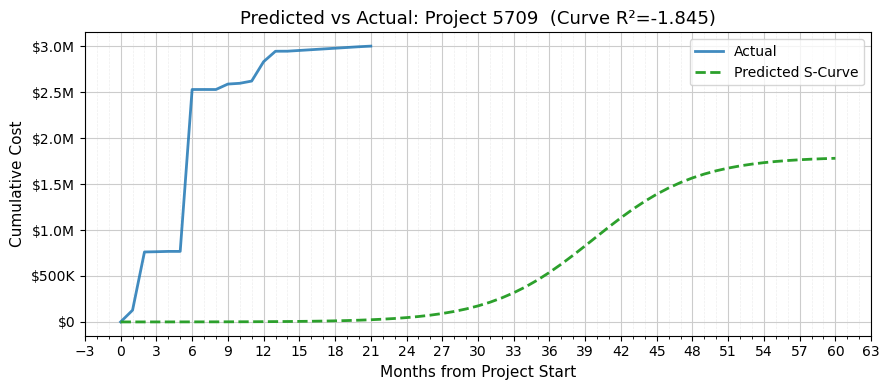

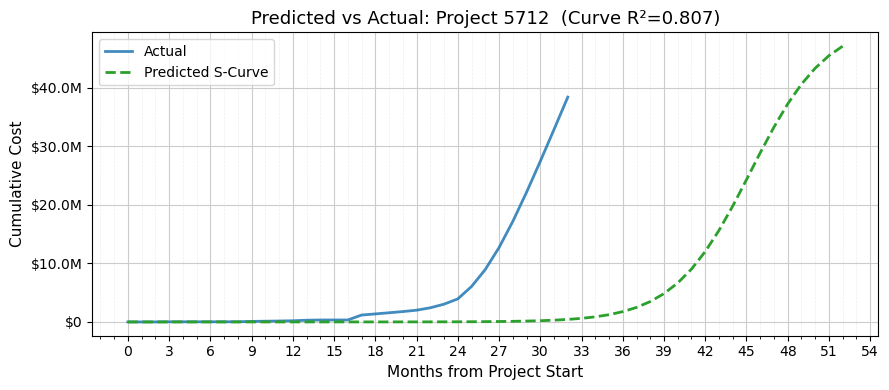

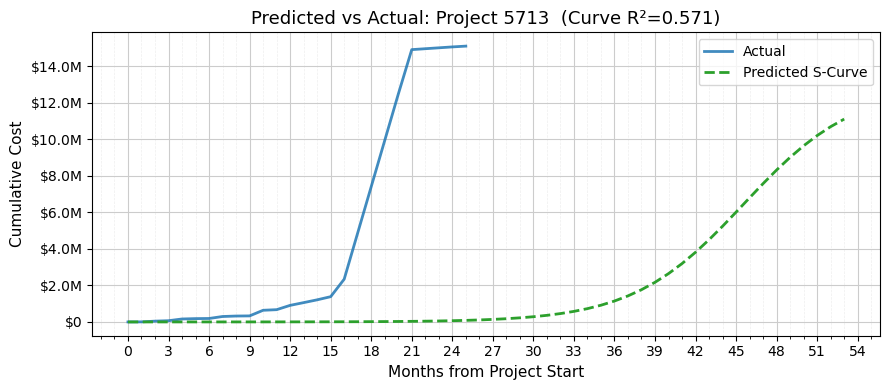

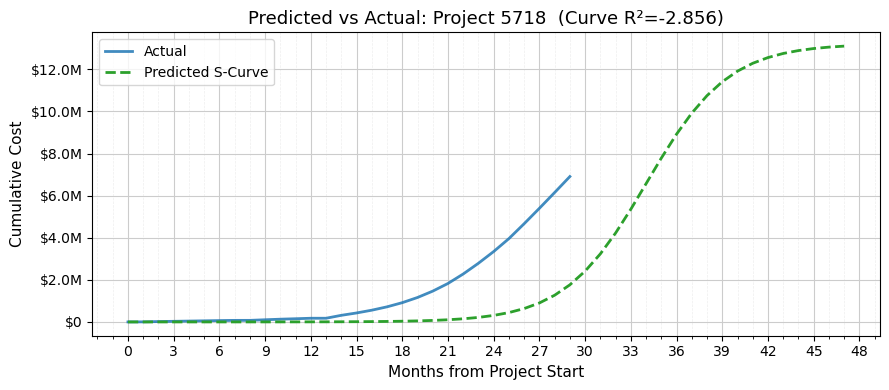

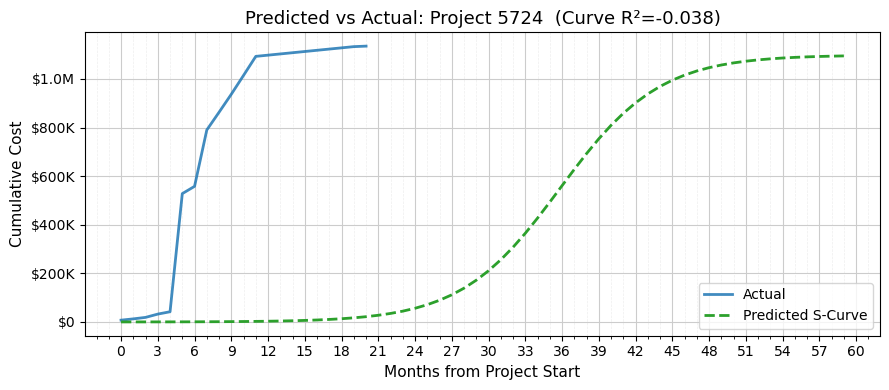

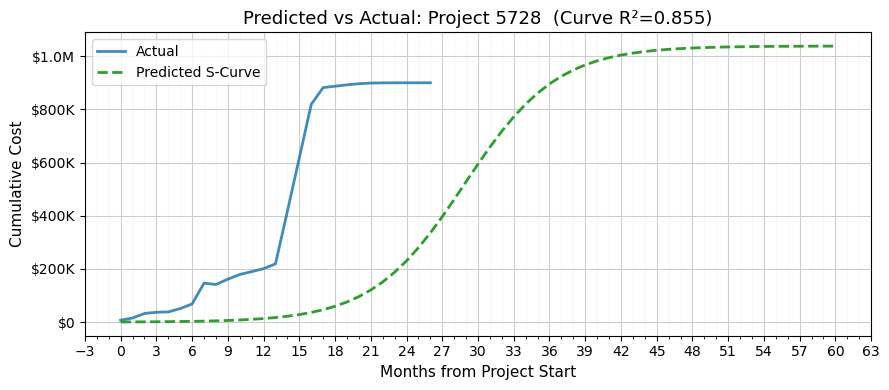

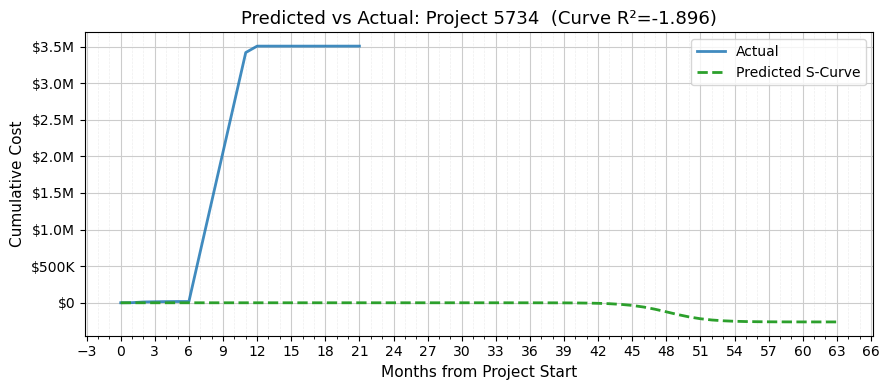

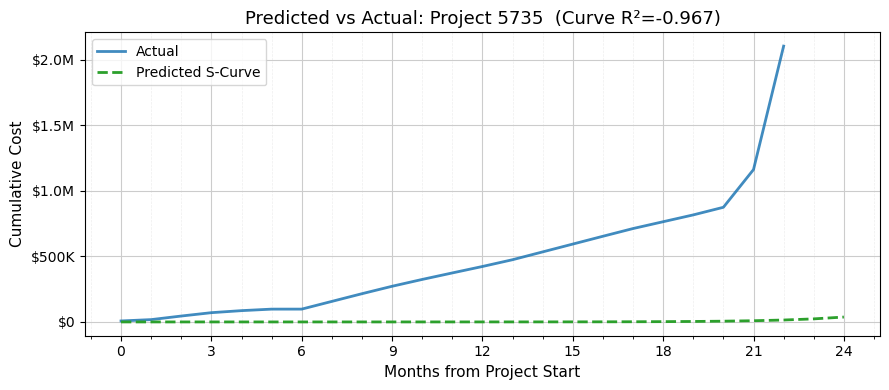

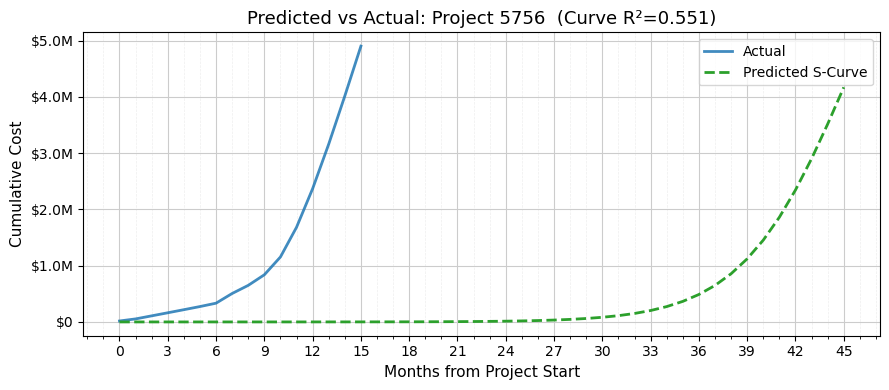

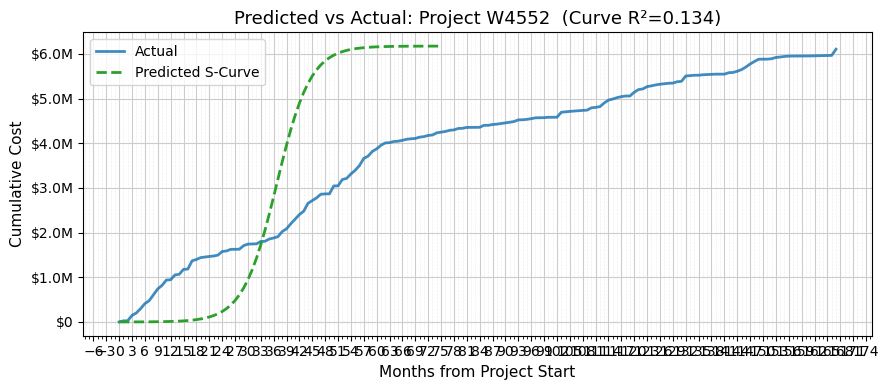

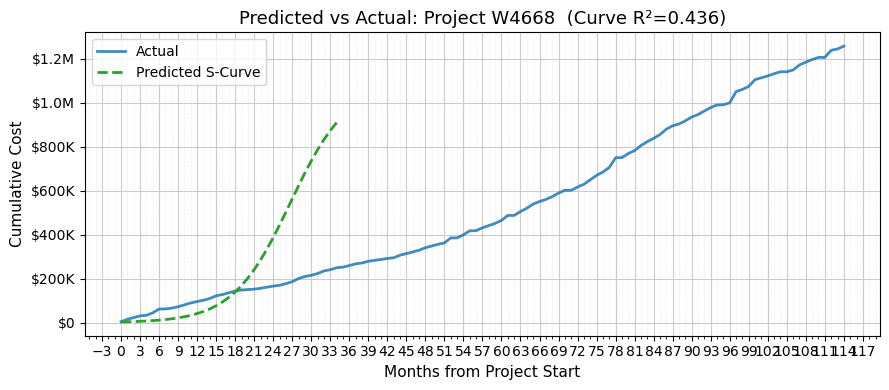

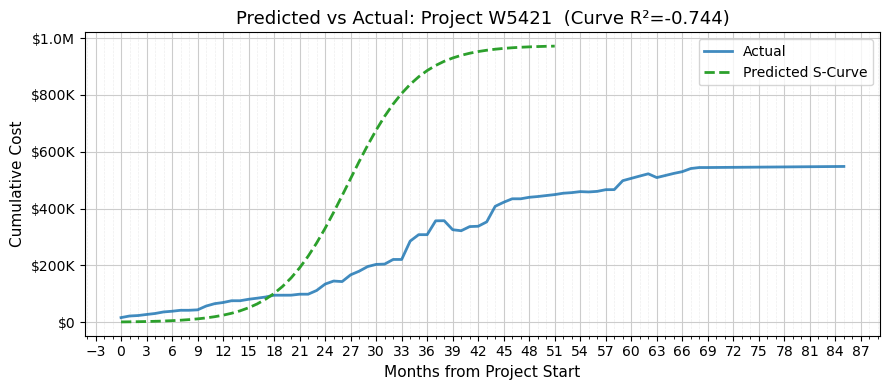

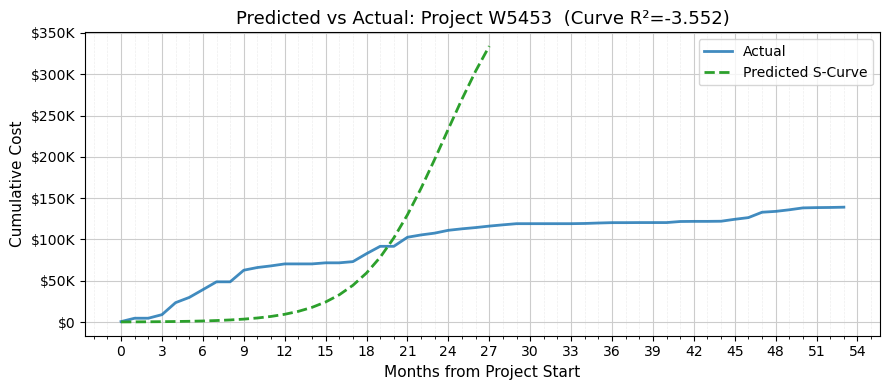

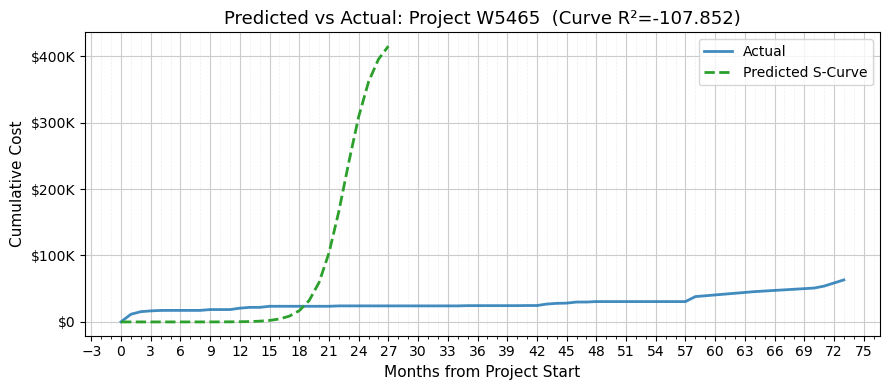

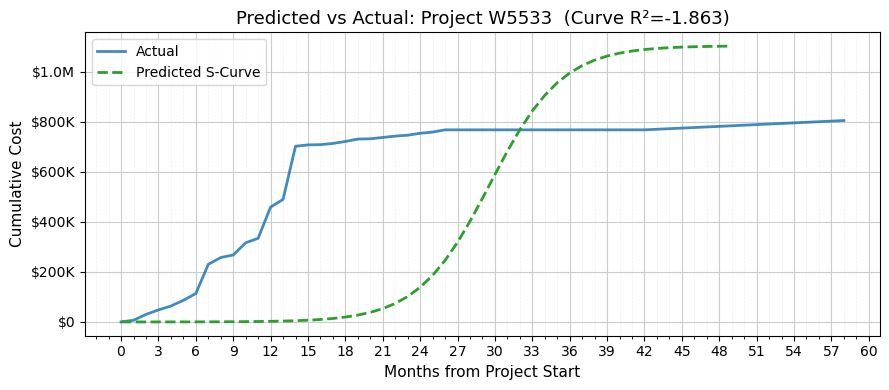

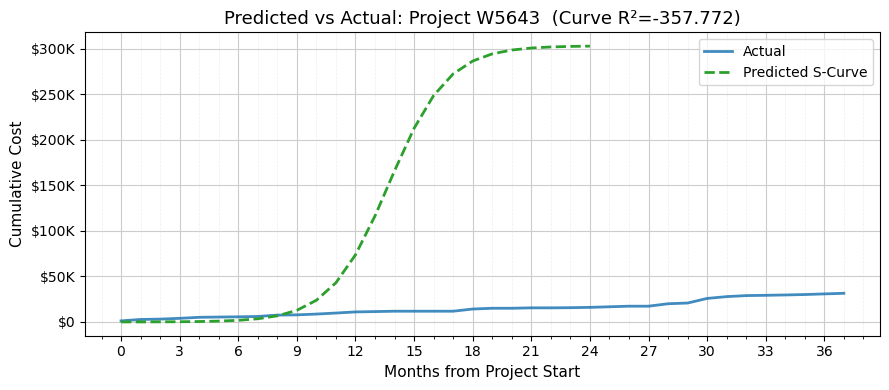

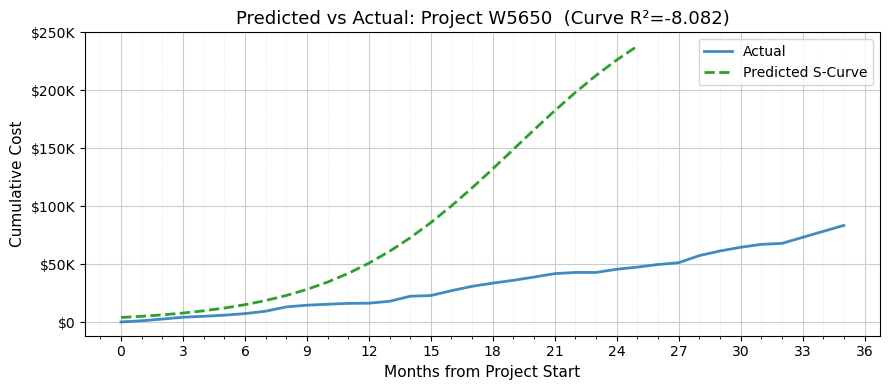

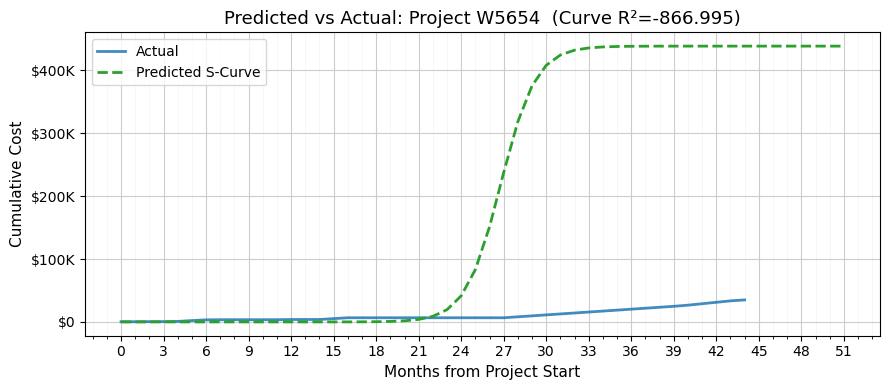

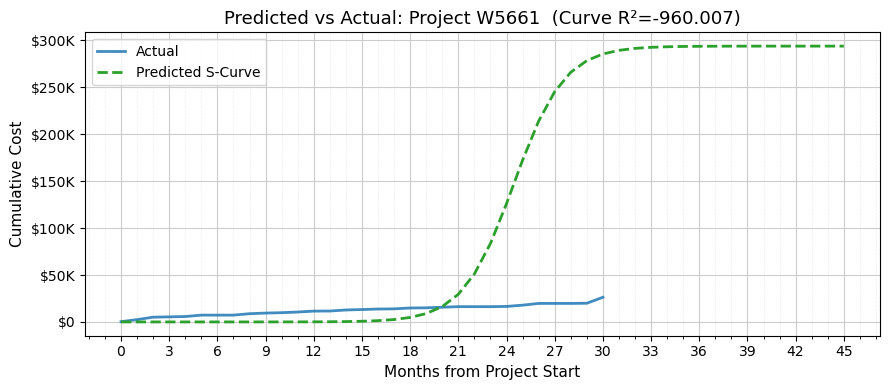

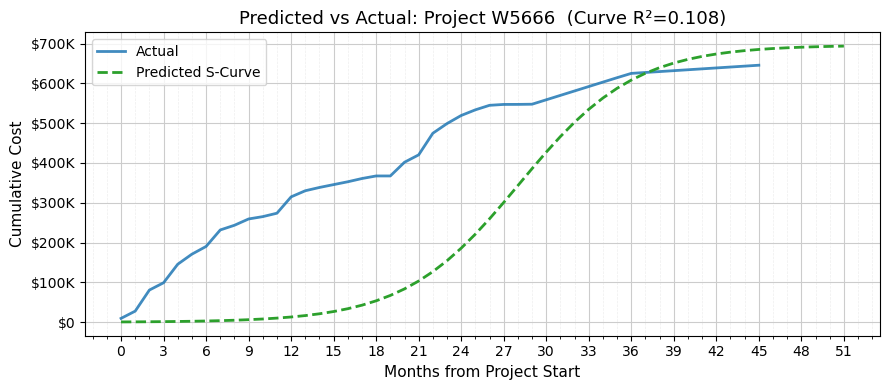

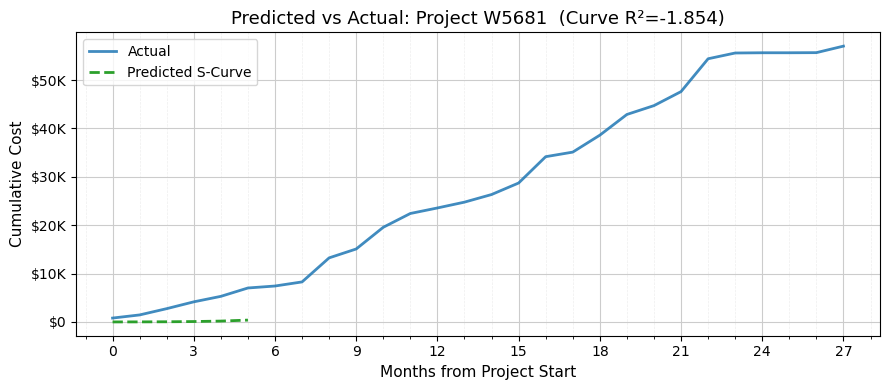

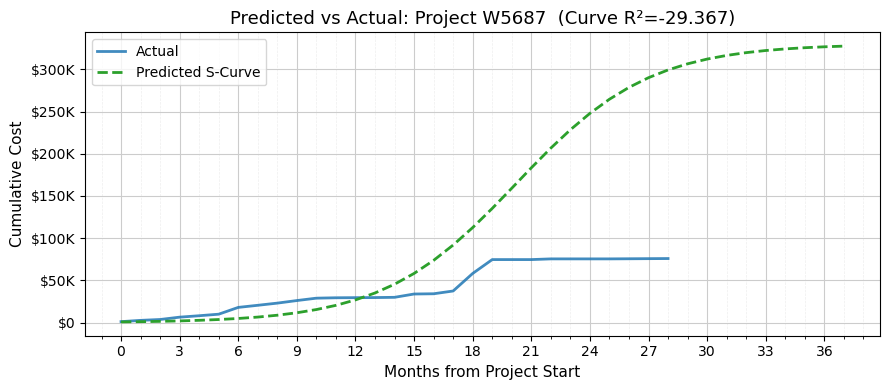

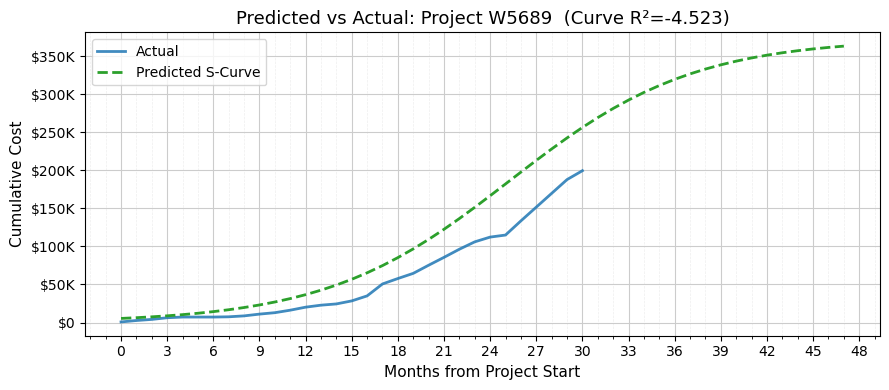

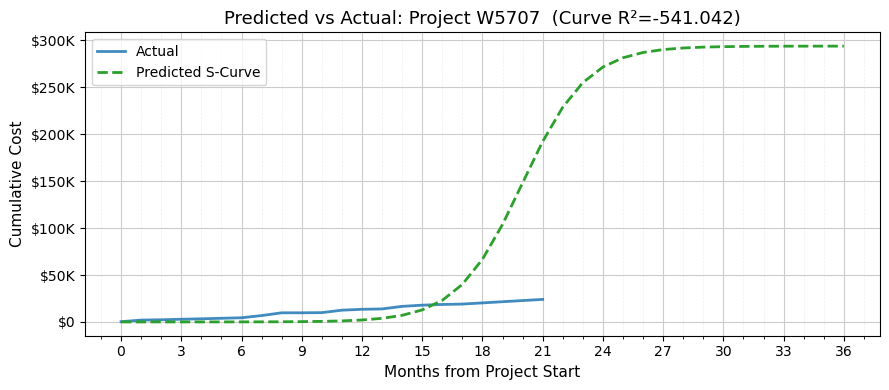

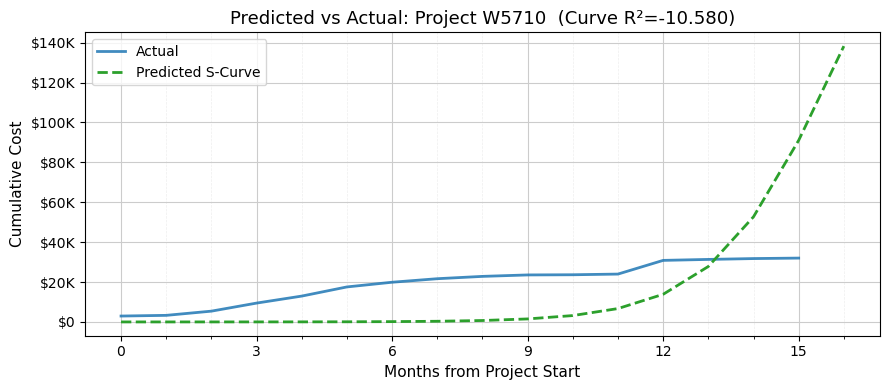

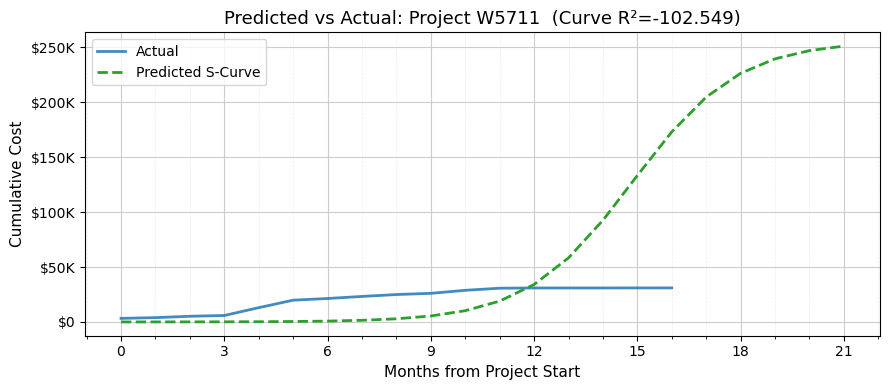

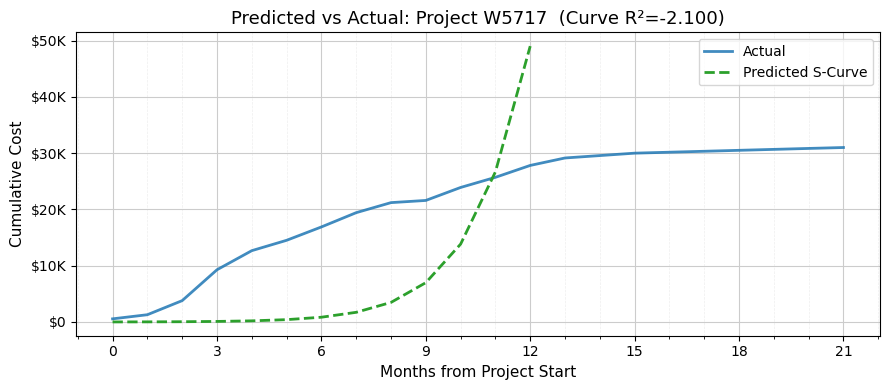

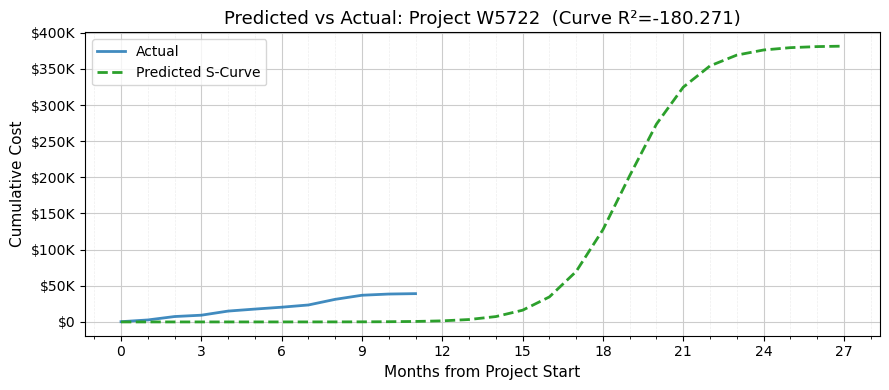

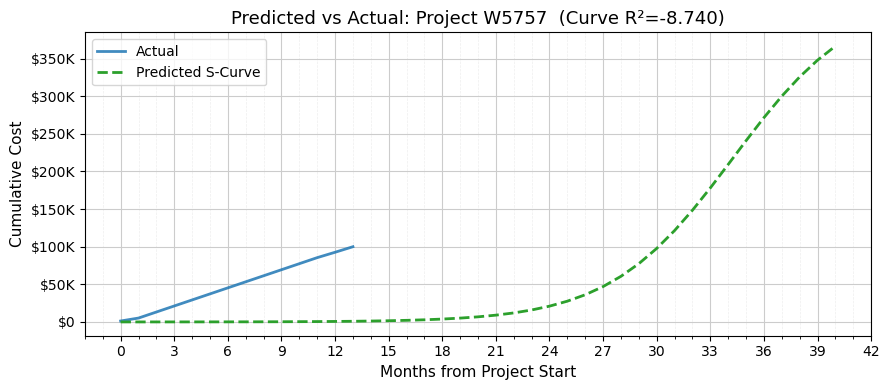


=== RECONSTRUCTION SUMMARY ===
Project Code    Curve_R2
       W5661 -960.007243
       W5654 -866.995460
        5590 -687.581262
       W5707 -541.041759
       W5643 -357.771714
        5576 -188.696846
       W5722 -180.270919
        5679 -154.197049
       W5465 -107.852280
       W5711 -102.548988
        5018  -43.702867
        5696  -42.779330
       W5687  -29.366883
        5105  -27.583710
        5586  -19.558981
        5558  -16.374580
       W5710  -10.580285
       W5757   -8.739874
       W5650   -8.081724
        5467   -7.034319
        5566   -6.391484
        5529   -5.811123
        5647   -5.665553
        5540   -4.857186
        5565   -4.558741
       W5689   -4.523234
        5530   -4.406254
        5198   -3.569242
       W5453   -3.551655
        5718   -2.856209
        5652   -2.189850
       W5717   -2.099859
        5697   -1.980080
        5734   -1.896350
       W5533   -1.863185
       W5681   -1.853618
        5709   -1.844697
        5046   -1.

In [ ]:
########################################################
"""

RECONSTRUCTION VALIDATION
Compare each project's predicted S-curve to its actual cumulative spend.
Uses LOO out-of-fold predictions — no data leakage.

"""
########################################################

from matplotlib.ticker import MultipleLocator, FuncFormatter

def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    return f'${x:,.0f}'

timeline_dates_full = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols_full  = timeline_dates_full.strftime('%b %Y').tolist()

reconstruction_results = []

for idx, row in all_projects_df.iterrows():
    pc = row['Project Code']
    actual_row = all_projects_df_2[all_projects_df_2['Project Code'] == pc]
    if actual_row.empty:
        continue

    y_full    = actual_row[timeline_cols_full].values[0].astype(float)
    start_i   = np.argmax(y_full > 0)
    actual_dur = max(1, int(row['Duration_Months']))
    y_actual  = y_full[start_i : start_i + actual_dur]

    pred_dur = max(1, int(loo_predictions['Duration_Months'][idx]))
    pred_L   = loo_predictions['S_Curve_L'][idx]
    pred_k   = loo_predictions['S_Curve_k'][idx]
    pred_t0  = loo_predictions['S_Curve_t0'][idx]

    y_pred_curve = logistic_curve(np.arange(pred_dur), pred_L, pred_k, pred_t0)

    # Interpolate to common length for R^2 comparison
    n   = min(pred_dur, actual_dur)
    y_a = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, actual_dur), y_actual)
    y_p = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, pred_dur),   y_pred_curve)
    ss_tot   = np.sum((y_a - y_a.mean()) ** 2)
    curve_r2 = 1 - np.sum((y_a - y_p) ** 2) / ss_tot if ss_tot > 0 else np.nan
    reconstruction_results.append({'Project Code': pc, 'Curve_R2': curve_r2})

    # Plot predicted vs actual
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(np.arange(actual_dur), y_actual,    linewidth=2, color='#1f77b4', label="Actual", alpha=0.85)
    ax.plot(np.arange(pred_dur),   y_pred_curve, linewidth=2, color='#2ca02c', linestyle='--', label="Predicted S-Curve")
    ax.set_title(f"Predicted vs Actual: Project {pc}  (Curve R²={curve_r2:.3f})", fontsize=13)
    ax.set_xlabel("Months from Project Start", fontsize=11)
    ax.set_ylabel("Cumulative Cost", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(which='major', color='#CCCCCC', linestyle='-',  linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

recon_df = pd.DataFrame(reconstruction_results)
print("\n=== RECONSTRUCTION SUMMARY ===")
print(recon_df.sort_values('Curve_R2').to_string(index=False))
print(f"\nMedian Curve R²: {recon_df['Curve_R2'].median():.4f}")
print(f"Projects with R² > 0.8: {(recon_df['Curve_R2'] > 0.8).sum()} / {len(recon_df)}")
